In [1]:
import numpy as np
import scipy as sp
import matplotlib as mpl
import matplotlib.pyplot as plt

# Mag(nu)s is imported as an installed package -- from the repository root,
# 'pip install -e .' (add [plot] for magnus.plotting). No sys.path juggling.
import magnus.oscprob as oscprob
import magnus.oscprobstd as oscprobstd
import magnus.hamiltonians as hamiltonians
import magnus.matter as matter
import magnus.earth as earth
import magnus.globaldefs as gd

# 0. Helper functions and definitions

In [2]:
col_full = '#E76F51'
col_ang = '#2A9D8F'
col_en = '#E9C46A'
col_count = '#73A8BF'#'#2A9D8F'


In [3]:
def prob_label(nu_i, nu_f):
    if (nu_i == gd.NUE):
        if (nu_f == gd.NUE):
            label = r'$P_{\nu_e \to \nu_e}$'
        elif (nu_f == gd.NUMU):
            label = r'$P_{\nu_e \to \nu_\mu}$'
        elif (nu_f == gd.NUTAU):
            label = r'$P_{\nu_e \to \nu_\tau}$'
    elif (nu_i == gd.NUMU):
        if (nu_f == gd.NUE):
            label = r'$P_{\nu_\mu \to \nu_e}$'
        elif (nu_f == gd.NUMU):
            label = r'$P_{\nu_\mu \to \nu_\mu}$'
        elif (nu_f == gd.NUTAU):
            label = r'$P_{\nu_\mu \to \nu_\tau}$'
    elif (nu_i == gd.NUTAU):
        if (nu_f == gd.NUE):
            label = r'$P_{\nu_\tau \to \nu_e}$'
        elif (nu_f == gd.NUMU):
            label = r'$P_{\nu_\tau \to \nu_\mu}$'
        elif (nu_f == gd.NUTAU):
            label = r'$P_{\nu_\tau \to \nu_\tau}$'
    return label

# 1. Probabilities 2$\nu$: in vacuum

## 1.1 General definitions

In [4]:
# Mixing parameters (predefined examples from globaldefs; can change them to anything else)
sth = gd.S12_NO_BF_NUFIT_6_0 # [adim]
Dm2 = gd.D21_NO_BF_NUFIT_6_0 # [eV^2]

## 1.2 Probabilities vs. distance

### Generate probabilities

In [5]:
# Baselines
l_ini, l_fin = 1.e1, 1.e5 # [km]
l_npts = 10000
distances = np.logspace(np.log10(l_ini), np.log10(l_fin), l_npts) # [km]

# Compute probability vs. baseline
# osc_prob and osc_prob_2nu_vacuum_std return a 2x2 NumPy array with the probabilities: [[Pee, Pem], [Pme, Pmm]]
nu_i, nu_f = gd.NUE, gd.NUE # Initial and final flavors; can also choose NUMU or NUTAU
energy = 10.0*gd.UNIT_MEV # [eV]
# Using standard formula
prob_std = np.array([oscprobstd.osc_prob_2nu_vacuum_std(sth, Dm2, energy, l*gd.CONV_KM_TO_INV_EV)[nu_i][nu_f] for l in distances])
# Using Magnus expansion
H_func = lambda l: hamiltonians.hamiltonian_2nu_vacuum(energy, sth, Dm2, compute_matrix_multiplication=False)
prob = np.array([oscprob.osc_prob(H_func, 0.0, l*gd.CONV_KM_TO_INV_EV, n_slabs=1, n_tpts_per_slab=10, magnus_exp_order=1)[nu_i][nu_f] \
                 for l in distances])

### Plot probabilities

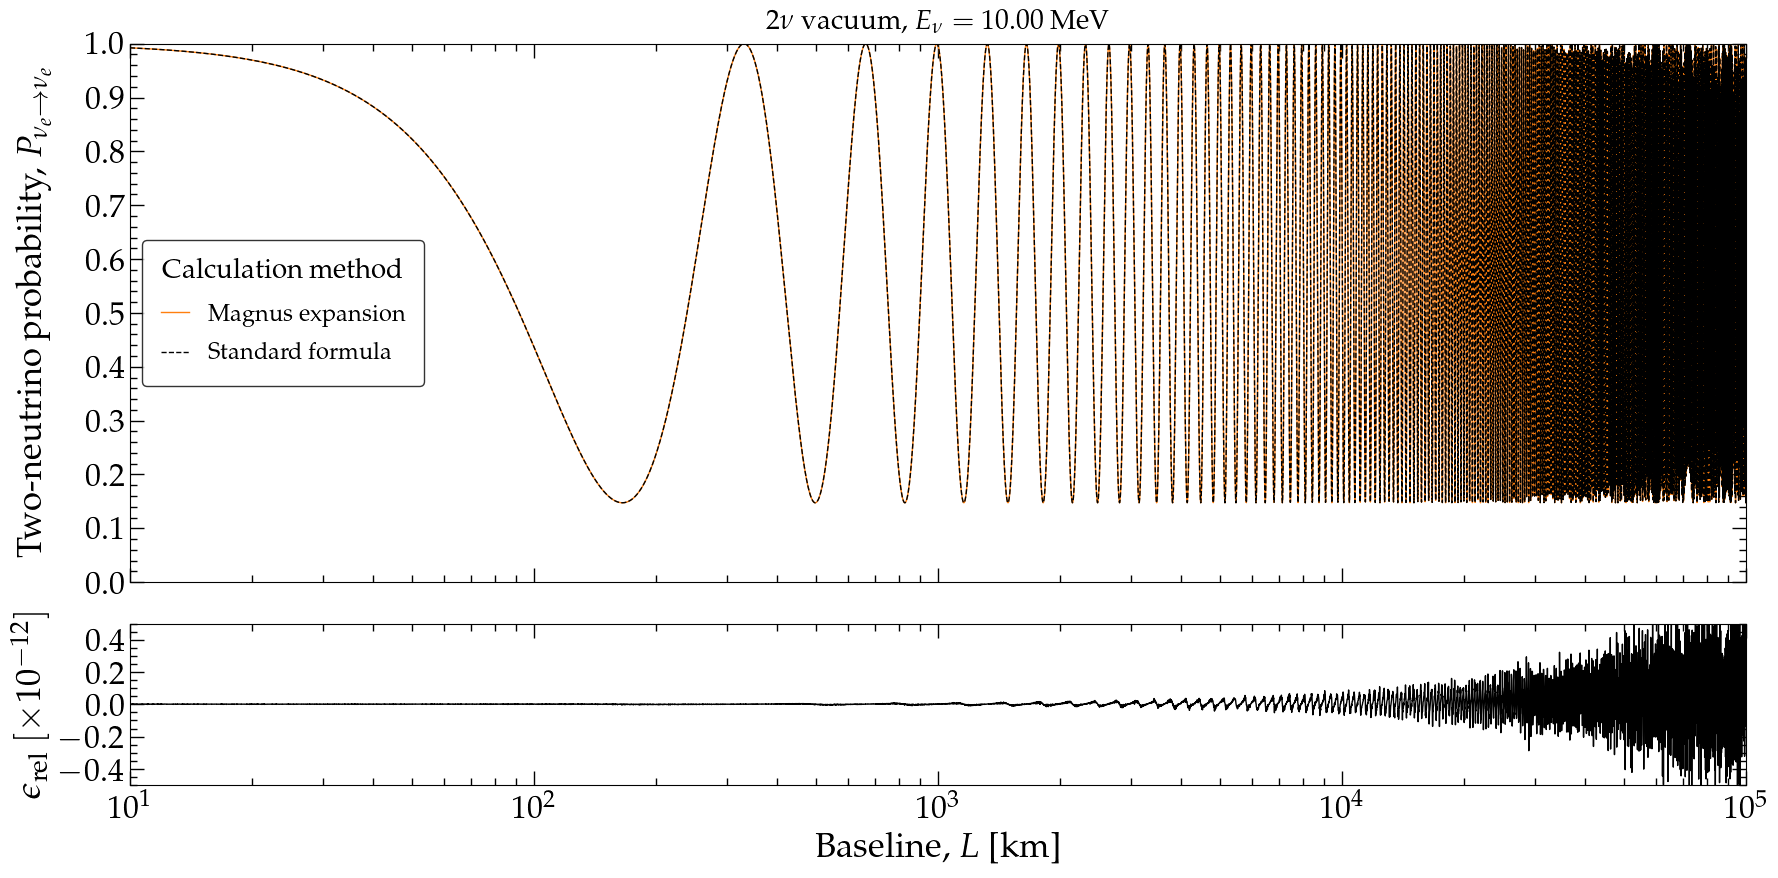

In [6]:
heights = [1.0, 0.3]
widths = [1.0]
gs_kw = dict(height_ratios=heights, width_ratios=widths)
fig, ax = plt.subplots(
    ncols=1, 
    nrows=2, 
    # constrained_layout=True, 
    gridspec_kw=gs_kw, 
    figsize=[18,9])
fig.subplots_adjust(hspace=0.05, wspace=0.05)

ax[0].plot(distances, prob, lw=1, color='C1', ls='-', label='Magnus expansion')
ax[0].plot(distances, prob_std, lw=1, color='k', ls='--', label='Standard formula')
ax[1].plot(distances, (prob-prob_std)/prob_std/1.e-12, lw=1, color='k', ls='-')

# Legend
ax[0].legend(fontsize=17, frameon=True, loc='center left', handlelength=1.2, handleheight=0.7,
             borderpad=0.8, title_fontsize=20, edgecolor='k', labelspacing=0.7, ncol=1,
             title=r'Calculation method')

# Formatting
ax[0].set_ylabel(r'Two-neutrino probability,~'+prob_label(nu_i, nu_f), labelpad=25)
ax[0].set_xlim(l_ini, l_fin)
ax[0].set_ylim(0, 1)
ax[0].set_xscale('log')
ax[0].yaxis.set_major_locator(mpl.ticker.MultipleLocator(base=0.10))
ax[0].yaxis.set_minor_locator(mpl.ticker.MultipleLocator(base=0.02))
ax[0].xaxis.set_ticklabels([])
ax[1].set_xlabel(r'Baseline, $L$ [km]')
ax[1].set_ylabel(r'$\epsilon_{\rm rel}~[\times 10^{-12}]$', labelpad=7)
ax[1].set_xscale('log')
ax[1].set_xlim(l_ini, l_fin)
ax[1].set_ylim(-0.5,0.5)
ax[1].yaxis.set_major_locator(mpl.ticker.MultipleLocator(base=0.20))
ax[1].yaxis.set_minor_locator(mpl.ticker.MultipleLocator(base=0.05))
ax[0].set_title(r'$2\nu$~vacuum, $E_\nu = $~{:.2f}~MeV'.format(energy/gd.UNIT_MEV), fontsize=20, pad=10)

# Save plot
plt.tight_layout()
plt.savefig('../fig/prob_2nu_vacuum_vs_baseline.pdf', dpi=200)

## 1.3 Probabilities vs. energy

### Generate probabilities

In [7]:
# Baselines
energy_min, energy_max = 1.e-1, 1.e1 # [GeV]
energy_npts = 5000
energies = np.logspace(np.log10(energy_min), np.log10(energy_max), energy_npts) # [GeV]

# Compute probability vs. energy
# osc_prob and osc_prob_2nu_vacuum_std return a 2x2 NumPy array with the probabilities: [[Pee, Pem], [Pme, Pmm]]
nu_i, nu_f = gd.NUE, gd.NUE # Initial and final flavors; can also choose NUMU or NUTAU
baseline = 5.e3 # [km]
# Using standard formula
prob_std = np.array([oscprobstd.osc_prob_2nu_vacuum_std(sth, Dm2, enu*gd.UNIT_GEV, baseline*gd.CONV_KM_TO_INV_EV)[nu_i][nu_f] \
                     for enu in energies])
# Using Magnus expansion
H = hamiltonians.hamiltonian_2nu_vacuum_energy_independent(sth, Dm2, compute_matrix_multiplication=False) # Vacuum H without (1/E)
prob = np.array([oscprob.osc_prob(lambda l: (1/(enu*gd.UNIT_GEV))*H, 
                                  0.0, gd.CONV_KM_TO_INV_EV*baseline, 
                                  n_slabs=1, n_tpts_per_slab=10, magnus_exp_order=1)[nu_i][nu_f] \
                 for enu in energies])

### Plot probabilities

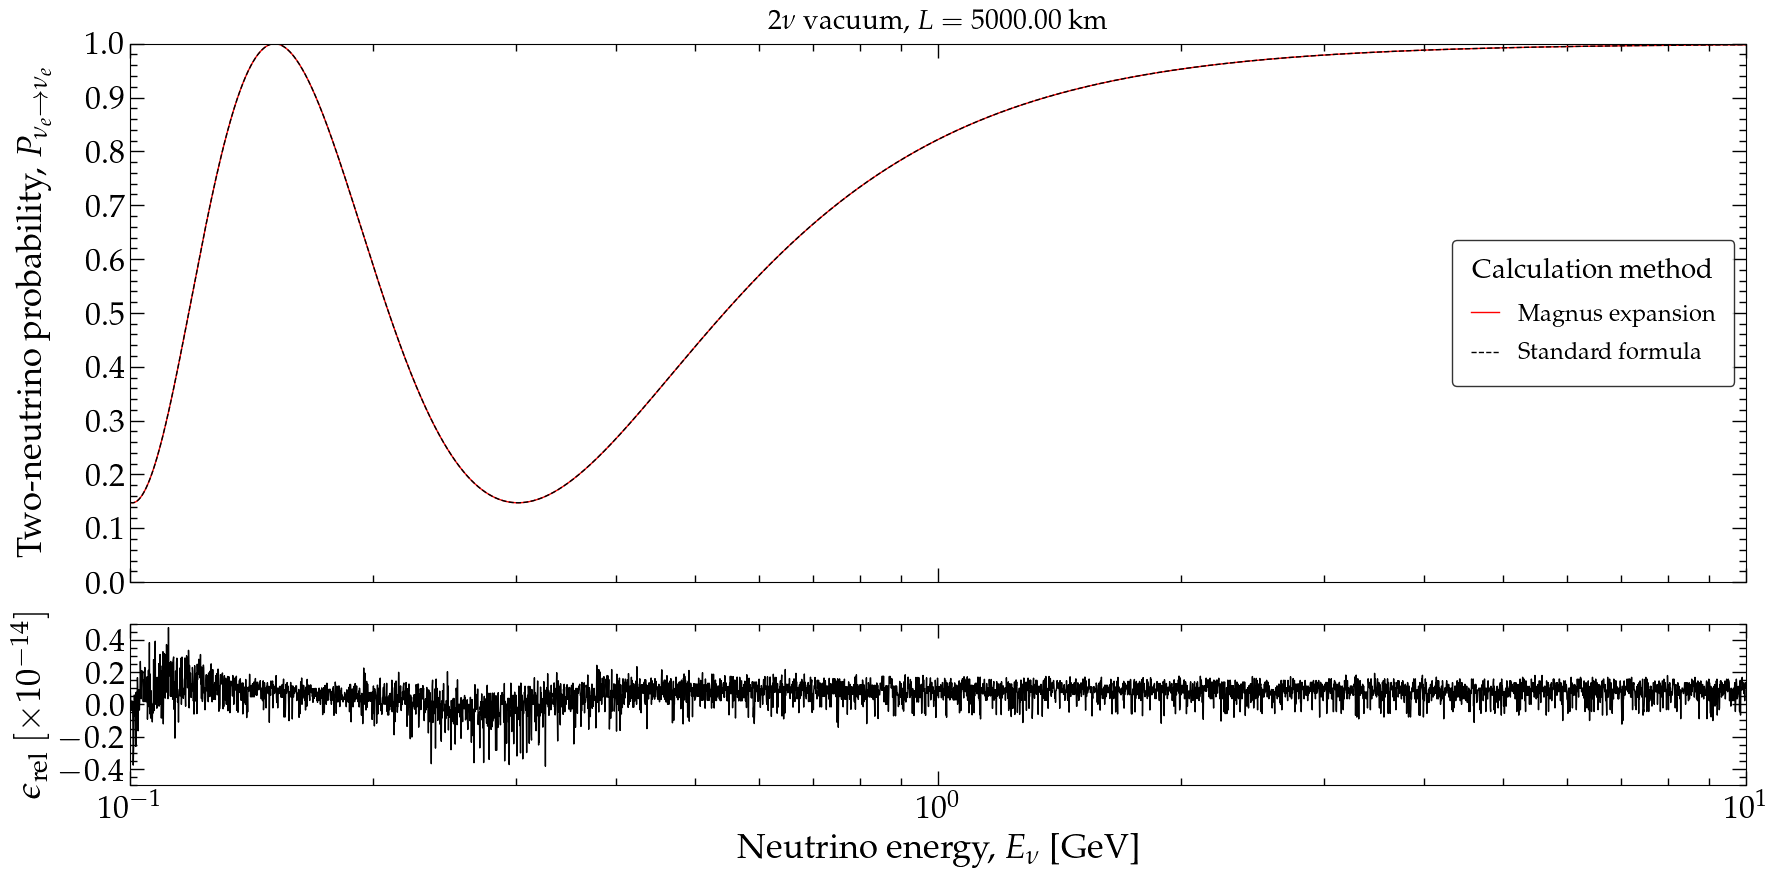

In [8]:
heights = [1.0, 0.3]
widths = [1.0]
gs_kw = dict(height_ratios=heights, width_ratios=widths)
fig, ax = plt.subplots(
    ncols=1, 
    nrows=2, 
    gridspec_kw=gs_kw, 
    figsize=[18,9])
fig.subplots_adjust(hspace=0.05, wspace=0.05)

ax[0].plot(energies, prob, lw=1, color='r', ls='-', label='Magnus expansion')
ax[0].plot(energies, prob_std, lw=1, color='k', ls='--', label='Standard formula')
ax[1].plot(energies, (prob-prob_std)/prob_std/1.e-14, lw=1, color='k', ls='-')

# Legend
ax[0].legend(fontsize=17, frameon=True, loc='center right', handlelength=1.2, handleheight=0.7,
             borderpad=0.8, title_fontsize=20, edgecolor='k', labelspacing=0.7, ncol=1,
             title=r'Calculation method')

# Formatting
ax[0].set_ylabel(r'Two-neutrino probability,~'+prob_label(nu_i, nu_f), labelpad=25)
ax[0].set_xlim(energy_min, energy_max)
ax[0].set_ylim(0, 1)
ax[0].set_xscale('log')
ax[0].yaxis.set_major_locator(mpl.ticker.MultipleLocator(base=0.10))
ax[0].yaxis.set_minor_locator(mpl.ticker.MultipleLocator(base=0.02))
ax[0].xaxis.set_ticklabels([])
ax[1].set_xlabel(r'Neutrino energy, $E_\nu$ [GeV]')
ax[1].set_ylabel(r'$\epsilon_{\rm rel}~[\times 10^{-14}]$', labelpad=7)
ax[1].set_xscale('log')
ax[1].set_xlim(energy_min, energy_max)
ax[1].set_ylim(-0.5,0.5)
ax[1].yaxis.set_major_locator(mpl.ticker.MultipleLocator(base=0.20))
ax[1].yaxis.set_minor_locator(mpl.ticker.MultipleLocator(base=0.05))
ax[0].set_title(r'$2\nu$~vacuum, $L = $~{:.2f}~km'.format(baseline), fontsize=20, pad=10)

# Save plot
plt.tight_layout()
plt.savefig('../fig/prob_2nu_vacuum_vs_energy.pdf', dpi=200)

# 2. Probabilities 2$\nu$: in matter with constant density

## 2.1 General definitions

In [9]:
# Mixing parameters (predefined examples from globaldefs; can change them to anything else)
sth = gd.S12_NO_BF_NUFIT_6_0 # [adim]
Dm2 = gd.D21_NO_BF_NUFIT_6_0 # [eV^2]

## 2.2 Probabilities vs. distance

### Generate probabilities

In [10]:
# Baselines
l_ini, l_fin = 1.e1, 1.e5 # [km]
l_npts = 10000
distances = np.logspace(np.log10(l_ini), np.log10(l_fin), l_npts) # [km]

# Compute probability vs. baseline
# osc_prob and osc_prob_2nu_vacuum_std return a 2x2 NumPy array with the probabilities: [[Pee, Pem], [Pme, Pmm]]
nu_i, nu_f = gd.NUE, gd.NUE # Initial and final flavors; can also choose NUMU or NUTAU
energy = 10.0*gd.UNIT_MEV # [eV]

# In matter
rho = 10.0 # Matter density [g cm^{-3}]
num_density_e = matter.num_density_e_func(l=0.0, density_matter_func=lambda l: rho, electron_fraction=0.5, density_matter_is_in_g_per_cm3=True) # Electron number density [eV^3]
VCC = matter.VCC_func(l=0.0, num_density_e_func=lambda l: num_density_e) # Coherent forward potential, VCC [eV]
# Using standard formula
prob_matt_std = np.array([oscprobstd.osc_prob_2nu_matter_std(sth, Dm2, VCC, energy, l*gd.CONV_KM_TO_INV_EV)[nu_i][nu_f] for l in distances])
# Using Magnus expansion
H_func = lambda l: hamiltonians.hamiltonian_2nu_vacuum(energy, sth, Dm2) + hamiltonians.hamiltonian_2nu_matter(VCC)
prob_matt = np.array([oscprob.osc_prob(H_func, 0, l*gd.CONV_KM_TO_INV_EV, 
                                       n_slabs=1, n_tpts_per_slab=10, magnus_exp_order=1)[nu_i][nu_f] for l in distances])

# In vacuum
# # Using standard formula
# prob_std = np.array([oscprobstd.osc_prob_2nu_vacuum_std(sth, Dm2, energy, l*gd.CONV_KM_TO_INV_EV)[nu_i][nu_f] for l in distances])
# Using Magnus expansion
H_func = lambda l: hamiltonians.hamiltonian_2nu_vacuum(energy, sth, Dm2)
prob_vac = np.array([oscprob.osc_prob(H_func, 0.0, l*gd.CONV_KM_TO_INV_EV, magnus_exp_order=1)[nu_i][nu_f] for l in distances])

### Plot probabilities

Text(0.5, 1.0, '$2\\nu$~constant-density matter, $E_\\nu = $~10.00~MeV')

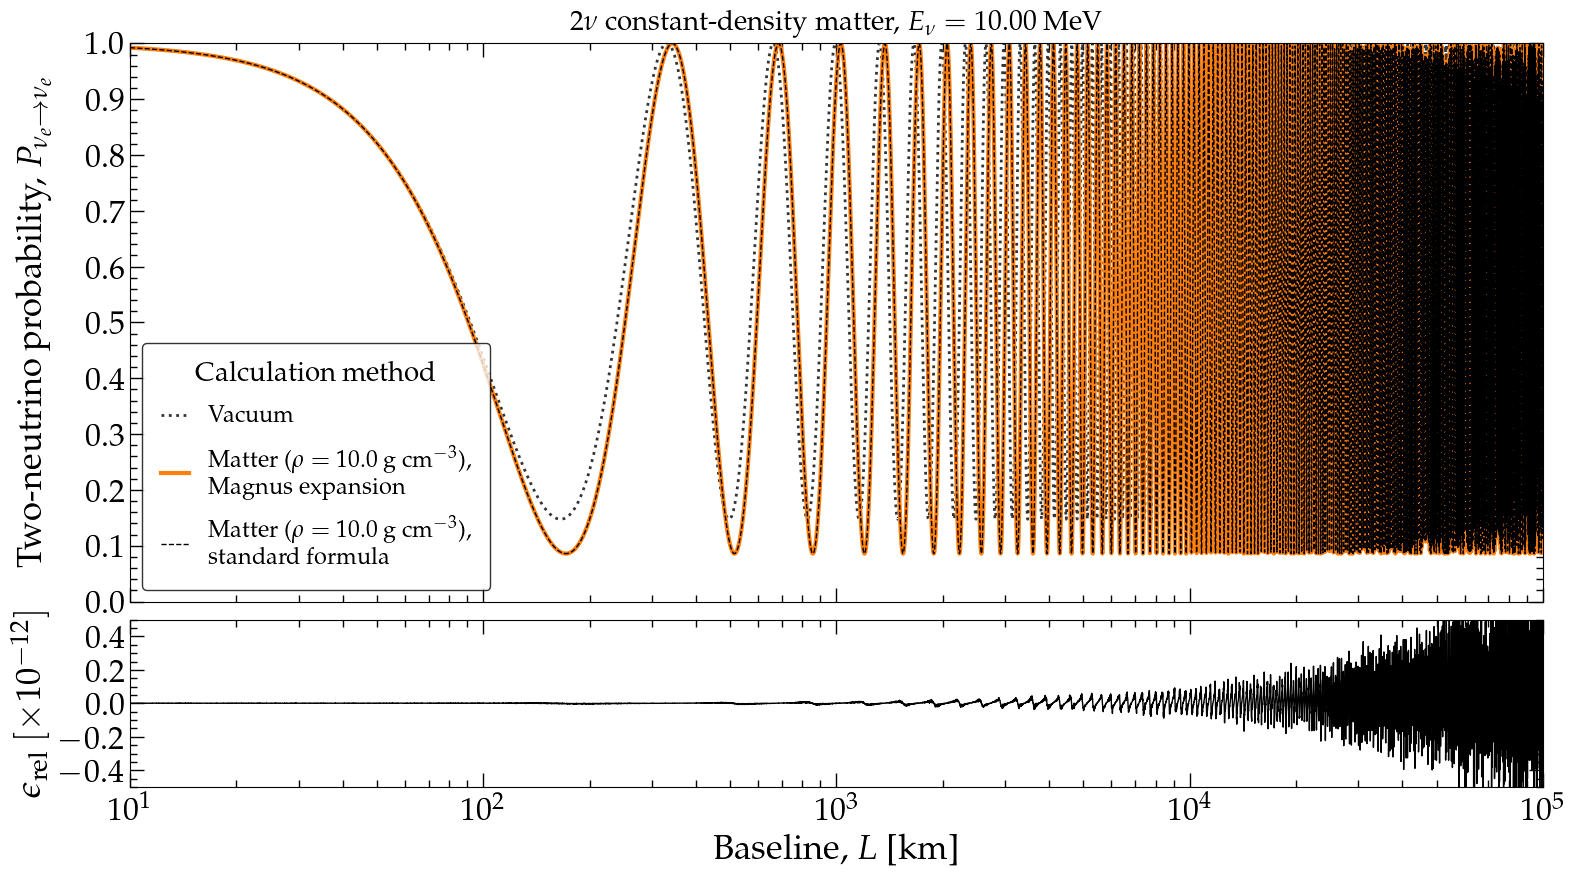

In [11]:
heights = [1.0, 0.3]
widths = [1.0]
gs_kw = dict(height_ratios=heights, width_ratios=widths)
fig, ax = plt.subplots(
    ncols=1, 
    nrows=2, 
    # constrained_layout=True, 
    gridspec_kw=gs_kw, 
    figsize=[18,9])
fig.subplots_adjust(hspace=0.05, wspace=0.05)

ax[0].plot(distances, prob_vac, lw=2, color='0.2', ls=':', label=r'Vacuum')
ax[0].plot(distances, prob_matt, lw=3, color='C1', ls='-', label=r'Matter ($\rho = $~{:.1f}'.format(rho)+r'~g~cm$^{-3}$),'
           +'\n'+'Magnus expansion')
ax[0].plot(distances, prob_matt_std, lw=1, color='k', ls='--', label=r'Matter ($\rho = $~{:.1f}'.format(rho)+r'~g~cm$^{-3}$),'
           +'\n'+'standard formula')
ax[1].plot(distances, (prob_matt-prob_matt_std)/prob_matt_std/1.e-12, lw=1, color='k', ls='-')

# Legend
ax[0].legend(fontsize=17, frameon=True, loc='lower left', handlelength=1.2, handleheight=0.7,
             borderpad=0.8, title_fontsize=20, edgecolor='k', labelspacing=0.7, ncol=1,
             title=r'Calculation method')

# Formatting
ax[0].set_ylabel(r'Two-neutrino probability,~'+prob_label(nu_i, nu_f), labelpad=25)
ax[0].set_xlim(l_ini, l_fin)
ax[0].set_ylim(0, 1)
ax[0].set_xscale('log')
ax[0].yaxis.set_major_locator(mpl.ticker.MultipleLocator(base=0.10))
ax[0].yaxis.set_minor_locator(mpl.ticker.MultipleLocator(base=0.02))
ax[0].xaxis.set_ticklabels([])
ax[1].set_xlabel(r'Baseline, $L$ [km]')
ax[1].set_ylabel(r'$\epsilon_{\rm rel}~[\times 10^{-12}]$', labelpad=7)
ax[1].set_xscale('log')
ax[1].set_xlim(l_ini, l_fin)
ax[1].set_ylim(-0.5,0.5)
ax[1].yaxis.set_major_locator(mpl.ticker.MultipleLocator(base=0.20))
ax[1].yaxis.set_minor_locator(mpl.ticker.MultipleLocator(base=0.05))
ax[0].set_title(r'$2\nu$~constant-density matter, $E_\nu = $~{:.2f}~MeV'.format(energy/gd.UNIT_MEV), fontsize=20, pad=10)

# Save plot
# plt.tight_layout()
# plt.savefig('../fig/prob_2nu_matter_const_density_vs_baseline.pdf', dpi=200)

## 2.3 Probabilities vs. energy

### Generate probabilities

In [12]:
# Baselines
energy_min, energy_max = 1.e-1, 1.e1 # [GeV]
energy_npts = 5000
energies = np.logspace(np.log10(energy_min), np.log10(energy_max), energy_npts) # [GeV]

# Compute probability vs. energy
# osc_prob and osc_prob_2nu_vacuum_std return a 2x2 NumPy array with the probabilities: [[Pee, Pem], [Pme, Pmm]]
nu_i, nu_f = gd.NUE, gd.NUE # Initial and final flavors; can also choose NUMU or NUTAU
baseline = 5.e3 # [km]

H_vac_energy_indep = hamiltonians.hamiltonian_2nu_vacuum_energy_independent(sth, Dm2) # Vacuum H without (1/E) [eV^2]
H_matt = hamiltonians.hamiltonian_2nu_matter(VCC) # [eV]

# In matter
rho = 10.0 # Matter density [g cm^{-3}]
num_density_e = matter.num_density_e_func(l=0.0, density_matter_func=lambda l: rho, electron_fraction=0.5, density_matter_is_in_g_per_cm3=True) # Electron number density [eV^3]
VCC = matter.VCC_func(l=0.0, num_density_e_func=lambda l: num_density_e) # Coherent forward potential, VCC [eV]
# Using standard formula
prob_matt_std = np.array([oscprobstd.osc_prob_2nu_matter_std(sth, Dm2, VCC, enu*gd.UNIT_GEV, baseline*gd.CONV_KM_TO_INV_EV)[nu_i][nu_f] \
                     for enu in energies])

# Using Magnus expansion
def H_func_const_density(l, energy):
    return (1/energy)*H_vac_energy_indep+H_matt
prob_matt = np.array([oscprob.osc_prob(lambda l: H_func_const_density(l, enu*gd.UNIT_GEV), 
                                       0.0, gd.CONV_KM_TO_INV_EV*baseline, magnus_exp_order=2)[nu_i][nu_f] for enu in energies])

# In vacuum
# # Using standard formula
# prob_vac = np.array([oscprobstd.osc_prob_2nu_vacuum_std(sth, Dm2, enu*gd.UNIT_GEV, baseline*gd.CONV_KM_TO_INV_EV)[nu_i][nu_f] \
#                      for enu in energies])
# Using Magnus expansion
H = hamiltonians.hamiltonian_2nu_vacuum_energy_independent(sth, Dm2) # Vacuum H without (1/E)
prob_vac = np.array([oscprob.osc_prob(lambda l: (1/(enu*gd.UNIT_GEV))*H, 0.0, gd.CONV_KM_TO_INV_EV*baseline, magnus_exp_order=2)[nu_i][nu_f] \
                 for enu in energies])

### Plot probabilities

Text(0.5, 1.0, '$2\\nu$~constant-density matter, $L = $~5000.00~km')

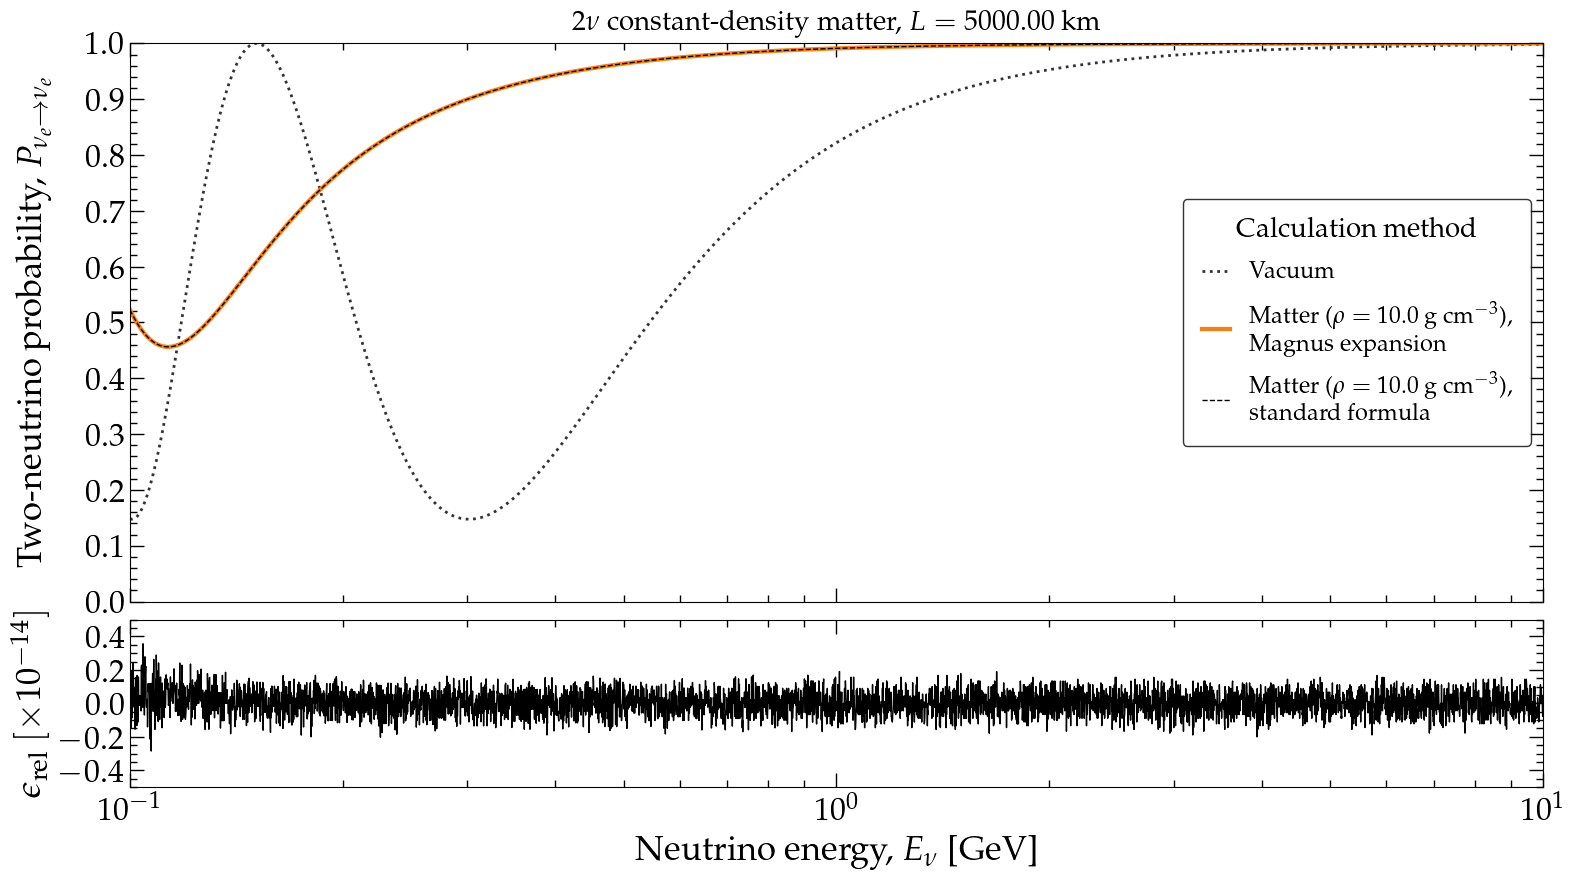

In [13]:
heights = [1.0, 0.3]
widths = [1.0]
gs_kw = dict(height_ratios=heights, width_ratios=widths)
fig, ax = plt.subplots(
    ncols=1, 
    nrows=2, 
    gridspec_kw=gs_kw, 
    figsize=[18,9])
fig.subplots_adjust(hspace=0.05, wspace=0.05)

ax[0].plot(energies, prob_vac, lw=2, color='0.2', ls=':', label=r'Vacuum')
ax[0].plot(energies, prob_matt, lw=3, color='C1', ls='-', label=r'Matter ($\rho = $~{:.1f}'.format(rho)+r'~g~cm$^{-3}$),'
           +'\n'+'Magnus expansion')
ax[0].plot(energies, prob_matt_std, lw=1, color='k', ls='--', label=r'Matter ($\rho = $~{:.1f}'.format(rho)+r'~g~cm$^{-3}$),'
           +'\n'+'standard formula')
ax[1].plot(energies, (prob_matt-prob_matt_std)/prob_matt_std/1.e-14, lw=1, color='k', ls='-')

# Legend
ax[0].legend(fontsize=17, frameon=True, loc='center right', handlelength=1.2, handleheight=0.7,
             borderpad=0.8, title_fontsize=20, edgecolor='k', labelspacing=0.7, ncol=1,
             title=r'Calculation method')

# Formatting
ax[0].set_ylabel(r'Two-neutrino probability,~'+prob_label(nu_i, nu_f), labelpad=25)
ax[0].set_xlim(energy_min, energy_max)
ax[0].set_ylim(0, 1)
ax[0].set_xscale('log')
ax[0].yaxis.set_major_locator(mpl.ticker.MultipleLocator(base=0.10))
ax[0].yaxis.set_minor_locator(mpl.ticker.MultipleLocator(base=0.02))
ax[0].xaxis.set_ticklabels([])
ax[1].set_xlabel(r'Neutrino energy, $E_\nu$ [GeV]')
ax[1].set_ylabel(r'$\epsilon_{\rm rel}~[\times 10^{-14}]$', labelpad=7)
ax[1].set_xscale('log')
ax[1].set_xlim(energy_min, energy_max)
ax[1].set_ylim(-0.5,0.5)
ax[1].yaxis.set_major_locator(mpl.ticker.MultipleLocator(base=0.20))
ax[1].yaxis.set_minor_locator(mpl.ticker.MultipleLocator(base=0.05))
ax[0].set_title(r'$2\nu$~constant-density matter, $L = $~{:.2f}~km'.format(baseline), fontsize=20, pad=10)

# Save plot
# plt.tight_layout()
# plt.savefig('../fig/prob_2nu_matter_const_density_vs_energy.pdf', dpi=200)

# 3. Probabilities 2$\nu$: in matter with varying density

## 3.1 General definitions

In [14]:
# Mixing parameters (predefined examples from globaldefs; can change them to anything else)
sth = gd.S12_NO_BF_NUFIT_6_0 # [adim]
Dm2 = gd.D21_NO_BF_NUFIT_6_0 # [eV^2]

In [15]:
# Parameters for the electron number density in the Sun, Eq. (10.62) in Giunti & Kim
num_density_e_center = 10*gd.N_AV/pow(gd.CONV_CM_TO_INV_EV,3.0) # [eV^3]
l_scale = 100.0 # [km]

H_vac_energy_indep = hamiltonians.hamiltonian_2nu_vacuum_energy_independent(sth, Dm2) # Vacuum H without (1/E) [eV^2]

# --------------------------------------------------------------
# In matter, constant density equal to central density
# --------------------------------------------------------------
# The matter density is constant, so this is merely a wrapper.
# [l] = km
VCC_center = matter.VCC_func(0.0, lambda l: num_density_e_center) # [eV]
H_matt_const_density = hamiltonians.hamiltonian_2nu_matter(VCC_center) # [eV]
def H_func_const_density(l, energy):
    return (1/energy)*H_vac_energy_indep+H_matt_const_density

# --------------------------------------------------------------
# In matter, exponentially falling density
# --------------------------------------------------------------
# [l] = km
def num_density_e_exp_func(l, num_density_e_center, l_scale):
    return num_density_e_center*np.exp(-(l/gd.CONV_KM_TO_INV_EV)/l_scale) # [eV^3]
def VCC_func_exp_density(l, num_density_e_center, l_scale):
    return matter.VCC_func(l, lambda r: num_density_e_exp_func(r, num_density_e_center, l_scale)) # [eV]
def H_func_exp_density(l, energy):
    return (1/energy)*H_vac_energy_indep+hamiltonians.hamiltonian_2nu_matter(VCC_func_exp_density(l, num_density_e_center, l_scale))


# --------------------------------------------------------------
# In matter, Gaussian density
# --------------------------------------------------------------
# [l] = km
num_density_e_basal = 0*gd.N_AV/pow(gd.CONV_CM_TO_INV_EV,3.0) # [eV^3]
num_density_e_central = 8*gd.N_AV/pow(gd.CONV_CM_TO_INV_EV,3.0) # [eV^3]
l_central, l_width = 300.0, 100.0 # [km]
def num_density_e_gaussian_func(l, num_density_e_central, l_central, l_width):
    return num_density_e_basal+num_density_e_central*np.exp( -(l/gd.CONV_KM_TO_INV_EV-l_central)**2/(2.0*l_width**2)) # [eV^3]
def VCC_func_gaussian_density(l, num_density_e_central, l_central, l_width):
    return matter.VCC_func(l, lambda r: num_density_e_gaussian_func(r, num_density_e_central, l_central, l_width)) # [eV]
def H_func_gaussian_density(l, energy):
    return (1/energy)*H_vac_energy_indep+hamiltonians.hamiltonian_2nu_matter(VCC_func_gaussian_density(l, 
                                                    num_density_e_central, l_central, l_width)) # [eV]

## 3.2 Probabilities vs. distance

### Generate probabilities

In [16]:
# Baselines
l_ini, l_fin = 5.e1, 1.e3 # [km]
l_npts = 10000
distances = np.logspace(np.log10(l_ini), np.log10(l_fin), l_npts) # [km]

# Compute probability vs. baseline
# osc_prob and osc_prob_2nu_vacuum_std return a 2x2 NumPy array with the probabilities: [[Pee, Pem], [Pme, Pmm]]
nu_i, nu_f = gd.NUE, gd.NUE # Initial and final flavors; can also choose NUMU or NUTAU
energy = 10.0*gd.UNIT_MEV # [eV]

# --------------------------------------------------------------
# In matter, constant density equal to central density
# --------------------------------------------------------------
prob_matt_const_density = np.array([oscprob.osc_prob(lambda l: H_func_const_density(l, energy), 
                                                     0, l*gd.CONV_KM_TO_INV_EV, 
                                                     n_slabs=1, n_tpts_per_slab=10, magnus_exp_order=1)[nu_i][nu_f] for l in distances])

# --------------------------------------------------------------
# In matter, exponentially falling density
# --------------------------------------------------------------
prob_matt_exp_density = np.array([oscprob.osc_prob(lambda l: H_func_exp_density(l, energy), 
                                                   0, l*gd.CONV_KM_TO_INV_EV, 
                                                   n_slabs=1, n_tpts_per_slab=10, magnus_exp_order=1)[nu_i][nu_f] for l in distances])

# --------------------------------------------------------------
# In matter, Gaussian density
# --------------------------------------------------------------
prob_matt_gaussian_density = np.array([oscprob.osc_prob(lambda l: H_func_gaussian_density(l, energy), 
                                                        0, l*gd.CONV_KM_TO_INV_EV, 
                                                        n_slabs=10, n_tpts_per_slab=10, magnus_exp_order=1)[nu_i][nu_f] for l in distances])

# --------------------------------------------------------------
# In vacuum
# --------------------------------------------------------------
H_vac = (1./energy)*H_vac_energy_indep # Can also call hamiltonians.hamiltonian_2nu_vacuum instead
prob_vac = np.array([oscprob.osc_prob(lambda l: H_vac,
                                      0.0, l*gd.CONV_KM_TO_INV_EV, 
                                      n_slabs=1, n_tpts_per_slab=10, magnus_exp_order=1)[nu_i][nu_f] for l in distances])

/home/mbustamante/Research/magnus/src/magnus/magnus.py:1040: MagnusConvergenceWarning: at least one time slab is too wide for guaranteed convergence of the Magnus series (||Omega||_2 >= pi); raising the expansion order will not help there -- more (narrower) slabs are needed. If a target tolerance (rtol/atol) was requested, the adaptive refinement narrows the slabs automatically and this warning can be ignored. Shown once per session.
  return evolution_operators_from_samples(At, widths, order,


### Plot probabilities

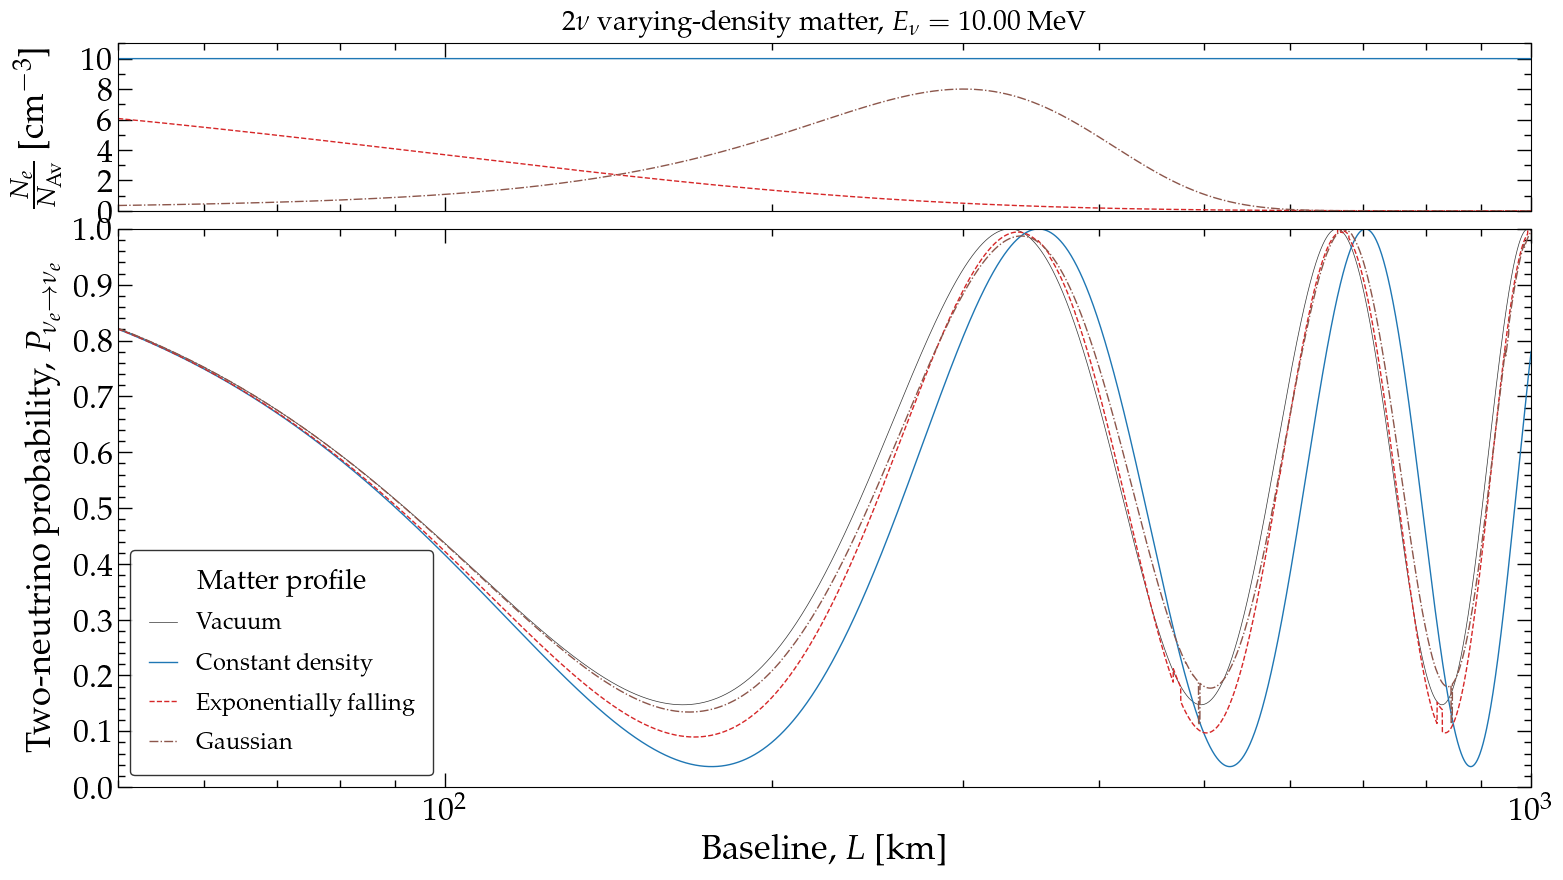

In [17]:
heights = [0.3, 1.0]
widths = [1.0]
gs_kw = dict(height_ratios=heights, width_ratios=widths)
fig, ax = plt.subplots(
    ncols=1, 
    nrows=2, 
    # constrained_layout=True, 
    gridspec_kw=gs_kw, 
    figsize=[18,9])
fig.subplots_adjust(hspace=0.05, wspace=0.05)

# Density profiles
ax[0].plot(distances, [num_density_e_center/(gd.N_AV/pow(gd.CONV_CM_TO_INV_EV,3.0)) for l in distances], lw=1, ls='-', c='C0')
ax[0].plot(distances, [num_density_e_exp_func(l*gd.CONV_KM_TO_INV_EV, num_density_e_center, l_scale)/(gd.N_AV/pow(gd.CONV_CM_TO_INV_EV,3.0)) \
                        for l in distances], lw=1, ls='--', c='C3')
ax[0].plot(distances, [num_density_e_gaussian_func(l*gd.CONV_KM_TO_INV_EV, num_density_e_central, l_central, l_width) \
                       / (gd.N_AV/pow(gd.CONV_CM_TO_INV_EV,3.0)) for l in distances], lw=1, ls='-.', c='C5')

# Probabilities
ax[1].plot(distances, prob_vac, lw=0.5, c='0.2', ls='-', label=r'Vacuum')
ax[1].plot(distances, prob_matt_const_density, lw=1, c='C0', ls='-', label=r'Constant density')
ax[1].plot(distances, prob_matt_exp_density, lw=1, c='C3', ls='--', label=r'Exponentially falling')
ax[1].plot(distances, prob_matt_gaussian_density, lw=1, c='C5', ls='-.', label=r'Gaussian')

# Legend
ax[1].legend(fontsize=17, frameon=True, loc='lower left', handlelength=1.2, handleheight=0.7,
             borderpad=0.8, title_fontsize=20, edgecolor='k', labelspacing=0.7, ncol=1, title=r'Matter profile')

# Formatting
# ax[0].set_ylabel(r'$N_e/N_{\rm Av}$~[cm$^{-3}$]', labelpad=15)
ax[0].set_ylabel(r'$\frac{N_e}{N_{\rm Av}}$~[cm$^{-3}$]', labelpad=15)
ax[0].set_xscale('log')
ax[0].set_xlim(l_ini, l_fin)
ax[0].set_ylim(0, 11)
ax[0].yaxis.set_major_locator(mpl.ticker.MultipleLocator(base=2))
ax[0].yaxis.set_minor_locator(mpl.ticker.MultipleLocator(base=1))
ax[0].xaxis.set_ticklabels([])
ax[0].set_title(r'$2\nu$~varying-density matter, $E_\nu = $~{:.2f}~MeV'.format(energy/gd.UNIT_MEV), fontsize=20, pad=10)
ax[1].set_xlabel(r'Baseline, $L$~[km]')
ax[1].set_ylabel(r'Two-neutrino probability,~'+prob_label(nu_i, nu_f), labelpad=10)
ax[1].set_xlim(l_ini, l_fin)
ax[1].set_ylim(0, 1)
ax[1].set_xscale('log')
ax[1].yaxis.set_major_locator(mpl.ticker.MultipleLocator(base=0.10))
ax[1].yaxis.set_minor_locator(mpl.ticker.MultipleLocator(base=0.02))

# Save plot
# plt.tight_layout()
# plt.savefig('../fig/prob_2nu_varying_density_vs_baseline.pdf', dpi=200)

## 3.3 Probabilities vs. energy

### Generate probabilities

In [18]:
# Energies
energy_min, energy_max = 1.e0, 1.e2 # [MeV]
energy_npts = 5000
energies = np.logspace(np.log10(energy_min), np.log10(energy_max), energy_npts) # [MeV]

# Compute probability vs. energy
# osc_prob and osc_prob_2nu_vacuum_std return a 2x2 NumPy array with the probabilities: [[Pee, Pem], [Pme, Pmm]]
nu_i, nu_f = gd.NUE, gd.NUE # Initial and final flavors; can also choose NUMU or NUTAU
baseline = 1.e3 # [km]

# --------------------------------------------------------------
# In matter, constant density equal to central density
# --------------------------------------------------------------
prob_matt_const_density = np.array([oscprob.osc_prob(lambda l: H_func_const_density(l, enu*gd.UNIT_MEV), 
                                                     0.0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                     n_slabs=1, n_tpts_per_slab=10, magnus_exp_order=1)[nu_i][nu_f] for enu in energies])

# --------------------------------------------------------------
# In matter, exponeitally falling density
# --------------------------------------------------------------
prob_matt_exp_density = np.array([oscprob.osc_prob(lambda l: H_func_exp_density(l, enu*gd.UNIT_MEV), 
                                                   0.0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                   n_slabs=20, n_tpts_per_slab=20, magnus_exp_order=3, n_jobs=10)[nu_i][nu_f] \
                                  for enu in energies])

# --------------------------------------------------------------
# In matter, Gaussian density
# --------------------------------------------------------------
prob_matt_gaussian_density = np.array([oscprob.osc_prob(lambda l: H_func_gaussian_density(l, enu*gd.UNIT_MEV), 
                                                        0.0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                        n_slabs=20, n_tpts_per_slab=20, magnus_exp_order=3, n_jobs=10)[nu_i][nu_f] \
                                  for enu in energies])

# --------------------------------------------------------------
# In vacuum
# --------------------------------------------------------------
prob_vac = np.array([oscprob.osc_prob(lambda l: (1/(enu*gd.UNIT_MEV))*H_vac_energy_indep, 
                                      0.0, baseline*gd.CONV_KM_TO_INV_EV, 
                                      n_slabs=1, n_tpts_per_slab=10, magnus_exp_order=1)[nu_i][nu_f] for enu in energies])

/home/mbustamante/Research/magnus/src/magnus/magnus.py:1040: MagnusConvergenceWarning: at least one time slab is too wide for guaranteed convergence of the Magnus series (||Omega||_2 >= pi); raising the expansion order will not help there -- more (narrower) slabs are needed. If a target tolerance (rtol/atol) was requested, the adaptive refinement narrows the slabs automatically and this warning can be ignored. Shown once per session.
  return evolution_operators_from_samples(At, widths, order,


### Plot probabilities

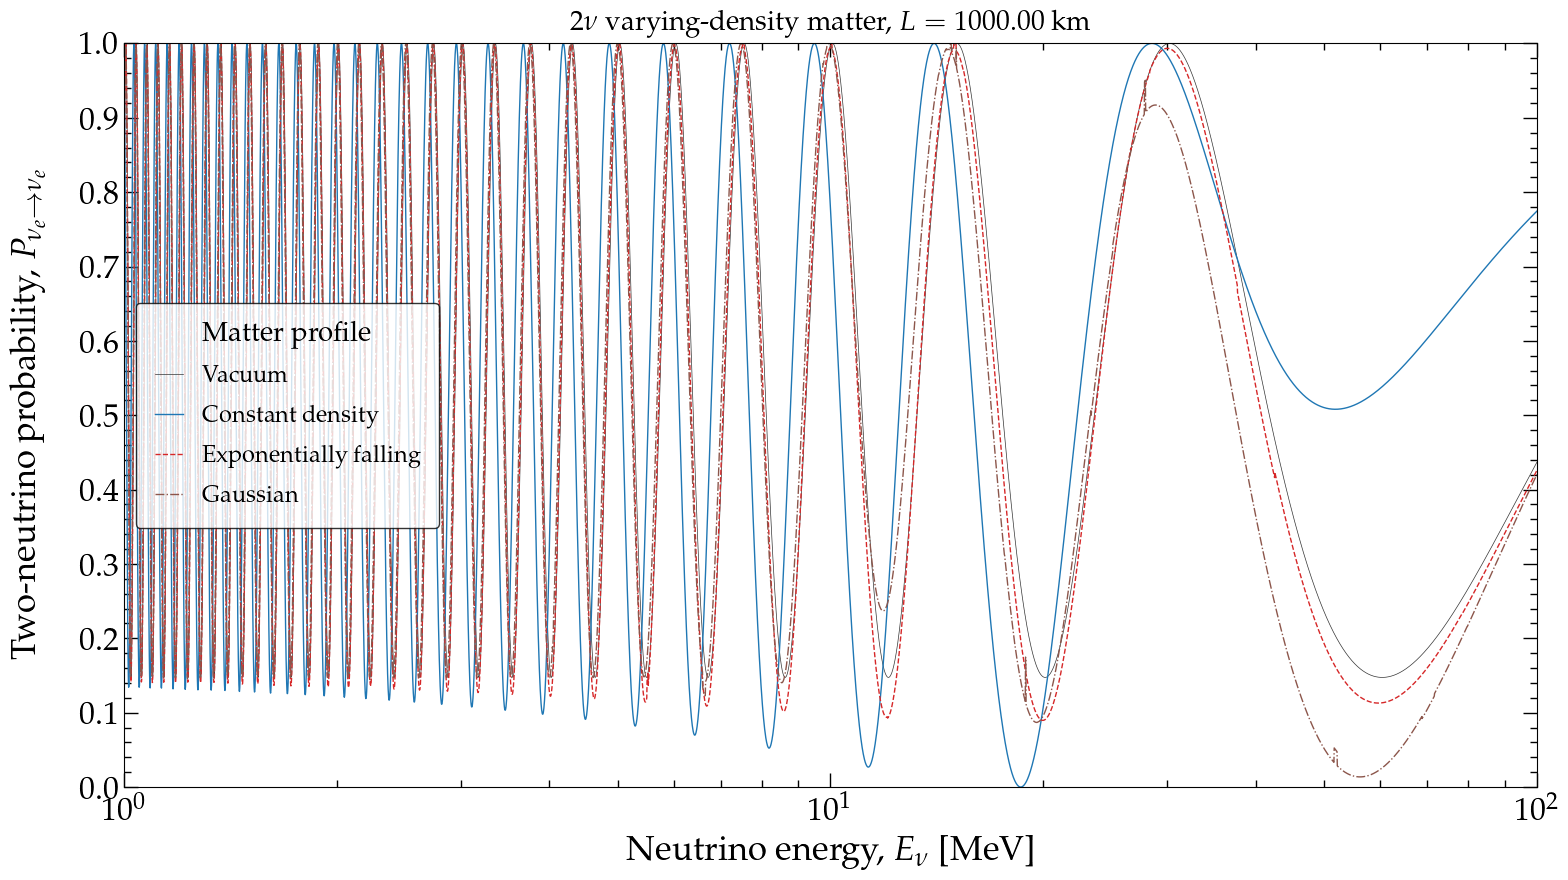

In [19]:
heights = [1.0]
widths = [1.0]
gs_kw = dict(height_ratios=heights, width_ratios=widths)
fig, ax = plt.subplots(
    ncols=1, 
    nrows=1, 
    gridspec_kw=gs_kw, 
    figsize=[18,9])
fig.subplots_adjust(hspace=0.05, wspace=0.05)

# Probabilities
ax.plot(energies, prob_vac, lw=0.5, c='0.2', ls='-', label=r'Vacuum')
ax.plot(energies, prob_matt_const_density, lw=1, c='C0', ls='-', label=r'Constant density')
ax.plot(energies, prob_matt_exp_density, lw=1, c='C3', ls='--', label=r'Exponentially falling')
ax.plot(energies, prob_matt_gaussian_density, lw=1, c='C5', ls='-.', label=r'Gaussian')

# Legend
ax.legend(fontsize=17, frameon=True, loc='center left', handlelength=1.2, handleheight=0.7, 
          borderpad=0.8, title_fontsize=20, edgecolor='k', labelspacing=0.7, ncol=1, title=r'Matter profile') 

# Formatting
ax.set_title(r'$2\nu$~varying-density matter, $L = $~{:.2f}~km'.format(baseline), fontsize=20, pad=10)
ax.set_xlabel(r'Neutrino energy, $E_\nu$ [MeV]')
ax.set_ylabel(r'Two-neutrino probability,~'+prob_label(nu_i, nu_f), labelpad=25)
ax.set_xlim(energy_min, energy_max)
ax.set_ylim(0, 1)
ax.set_xscale('log')
ax.yaxis.set_major_locator(mpl.ticker.MultipleLocator(base=0.10))
ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(base=0.02))

# Save plot
# plt.tight_layout()
# plt.savefig('../fig/prob_2nu_varying_density_vs_energy.pdf', dpi=200)

# 4. Probabilities 2$\nu$: in matter with castle-wall density profile

## 4.1 General definitions

In [20]:
# Mixing parameters (predefined examples from globaldefs; can change them to anything else)
sth = gd.S12_NO_BF_NUFIT_6_0 # [adim]
Dm2 = gd.D21_NO_BF_NUFIT_6_0 # [eV^2]

In [21]:
# Low and high densities of the castle-wall density profile
num_density_e_low = 1*gd.N_AV/pow(gd.CONV_CM_TO_INV_EV,3.0) # [eV^3]
num_density_e_high = 10*gd.N_AV/pow(gd.CONV_CM_TO_INV_EV,3.0) # [eV^3]
num_density_e_avg = (num_density_e_high-num_density_e_low)/2.0 # [eV^3]

H_vac_energy_indep = hamiltonians.hamiltonian_2nu_vacuum_energy_independent(sth, Dm2) # Vacuum H without (1/E) [eV^2]
    
# --------------------------------------------------------------
# In matter, constant density
# --------------------------------------------------------------
# The matter density is constant, so this is merely a wrapper ([l] = km)
VCC_avg = matter.VCC_func(0.0, lambda l: num_density_e_avg) # [eV]
H_matt_const_density = hamiltonians.hamiltonian_2nu_matter(VCC_avg) # [eV]
def H_func_const_density(l, energy):
    return (1/energy)*H_vac_energy_indep+H_matt_const_density

# --------------------------------------------------------------
# In matter, castle-wall density profile
# --------------------------------------------------------------
# [l] = km
def num_density_e_castle_wall_func(l, num_density_e_low, num_density_e_high, n_castle_slabs, l_ini, l_fin):
    l_scaled = (l/gd.CONV_KM_TO_INV_EV-l_ini)/(l_fin-l_ini)
    dl = 1.0/n_castle_slabs # Width of one slab
    index_slab = l_scaled // dl
    # The first slab has low density, the second one has high density, and so on
    if (index_slab % 2) == 0:
        return num_density_e_low
    else:
        return num_density_e_high
def VCC_func_castle_wall(l, num_density_e_low, num_density_e_high, n_castle_slabs, l_ini, l_fin):
    return matter.VCC_func(l, lambda r: num_density_e_castle_wall_func(r, num_density_e_low, num_density_e_high, 
                                                                       n_castle_slabs, l_ini, l_fin)) # [eV]
def H_func_castle_wall(l, energy, num_density_e_low, num_density_e_high, n_castle_slabs, l_ini, l_fin):
    return (1/energy)*H_vac_energy_indep+hamiltonians.hamiltonian_2nu_matter(VCC_func_castle_wall(l, 
                                                                                        num_density_e_low, num_density_e_high,
                                                                                        n_castle_slabs, l_ini, l_fin))

n_castle_slabs_narrow = 50 # Narrow castle wall
n_castle_slabs_wide = 10   # Wide castle wall

## 4.2 Probabilities vs. distance

### Generate probabilities

In [22]:
# Baselines
l_ini, l_fin = 1.e2, 1.e4 #1.e2, 1.e5 # [km]
l_npts = 6000 
distances = np.logspace(np.log10(l_ini), np.log10(l_fin), l_npts) # [km]

# Compute probability vs. baseline
# osc_prob and osc_prob_2nu_vacuum_std return a 2x2 NumPy array with the probabilities: [[Pee, Pem], [Pme, Pmm]]
nu_i, nu_f = gd.NUE, gd.NUE # Initial and final flavors; can also choose NUMU or NUTAU
energy = 50.*gd.UNIT_MEV # [eV] #10

#--------------------------------------------------------------
# In matter, constant density
# --------------------------------------------------------------
prob_matt_const_density = np.array([oscprob.osc_prob(lambda l: H_func_const_density(l, energy), 
                                                     0, l*gd.CONV_KM_TO_INV_EV, 
                                                     n_slabs=1, n_tpts_per_slab=10, magnus_exp_order=1)[nu_i][nu_f] for l in distances])

# --------------------------------------------------------------
# In matter, narrow castle-wall density profile
# --------------------------------------------------------------
prob_matt_castle_wall_narrow = np.array([oscprob.osc_prob(lambda l: H_func_castle_wall(l, energy, num_density_e_low, num_density_e_high, 
                                                                                       n_castle_slabs_narrow, l_ini, l_fin), 
                                                     0, l*gd.CONV_KM_TO_INV_EV, 
                                                     n_slabs=150, n_tpts_per_slab=100, magnus_exp_order=3, n_jobs=10)[nu_i][nu_f] \
                                          for l in distances]) 

# --------------------------------------------------------------
# In matter, constant density, low-amplitude noise
# --------------------------------------------------------------
prob_matt_castle_wall_wide = np.array([oscprob.osc_prob(lambda l: H_func_castle_wall(l, energy, num_density_e_low, num_density_e_high,
                                                                                     n_castle_slabs_wide, l_ini, l_fin), 
                                                     0, l*gd.CONV_KM_TO_INV_EV, 
                                                     n_slabs=150, n_tpts_per_slab=100, magnus_exp_order=3, n_jobs=10)[nu_i][nu_f] \
                                          for l in distances]) 

/home/mbustamante/Research/magnus/src/magnus/magnus.py:1040: MagnusConvergenceWarning: at least one time slab is too wide for guaranteed convergence of the Magnus series (||Omega||_2 >= pi); raising the expansion order will not help there -- more (narrower) slabs are needed. If a target tolerance (rtol/atol) was requested, the adaptive refinement narrows the slabs automatically and this warning can be ignored. Shown once per session.
  return evolution_operators_from_samples(At, widths, order,


### Plot probabilities

Text(0.5, 0, 'Baseline, $L$~[km]')

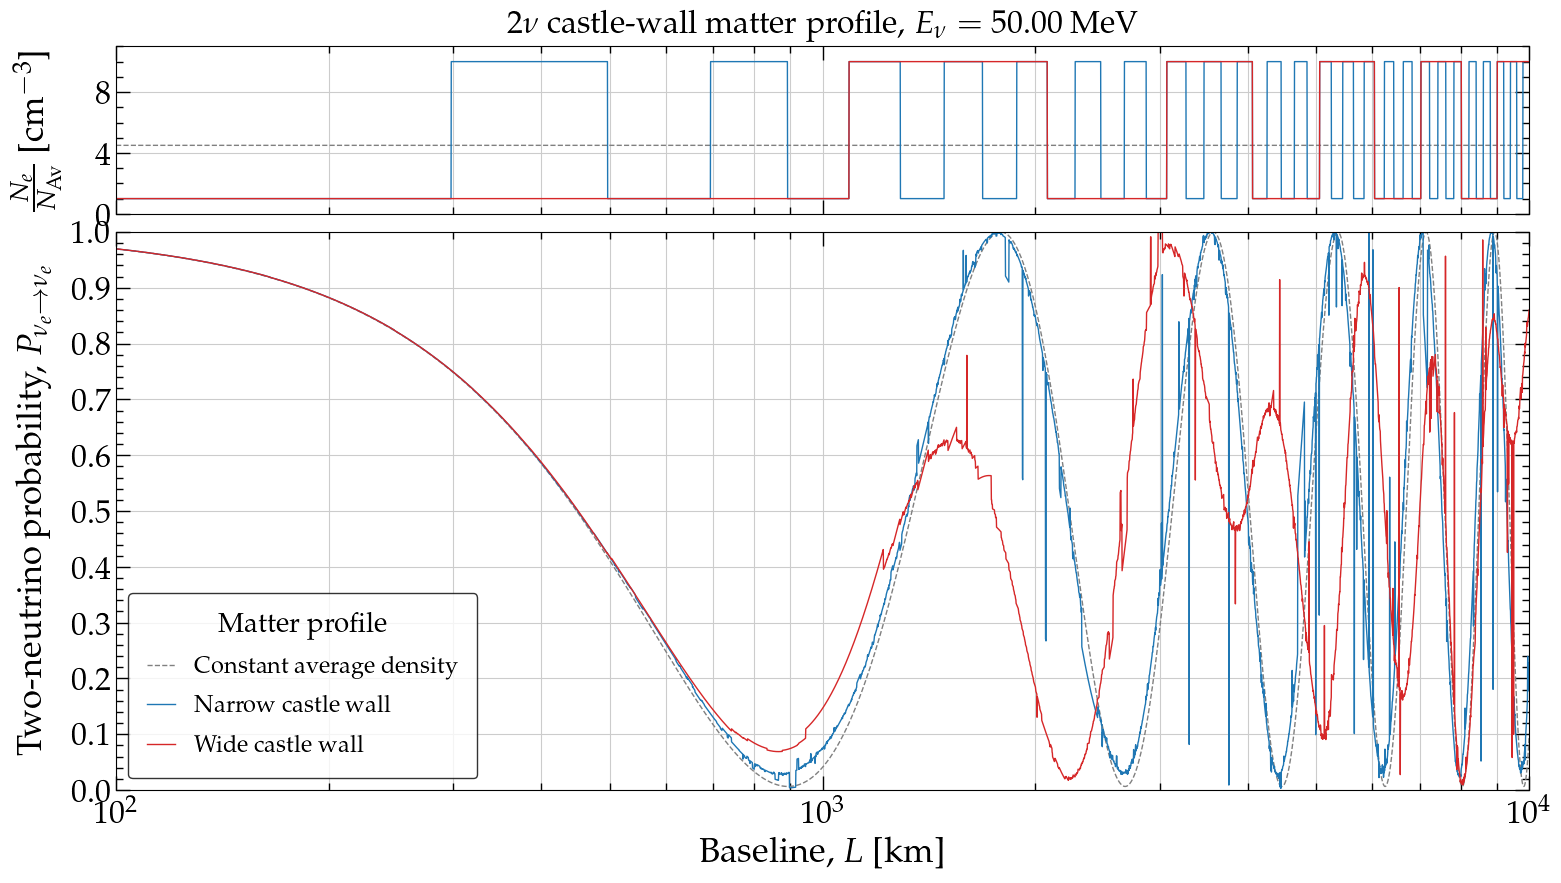

In [23]:
heights = [0.3, 1.0]
widths = [1.0]
gs_kw = dict(height_ratios=heights, width_ratios=widths)
fig, ax = plt.subplots(
    ncols=1, 
    nrows=2, 
    # constrained_layout=True, 
    gridspec_kw=gs_kw, 
    figsize=[18,9])
fig.subplots_adjust(hspace=0.05, wspace=0.05)

# Density profiles
ax[0].plot(distances, [num_density_e_avg/(gd.N_AV/pow(gd.CONV_CM_TO_INV_EV,3.0)) for l in distances], lw=1, ls='--', c='0.5')
ax[0].plot(distances, [num_density_e_castle_wall_func(l*gd.CONV_KM_TO_INV_EV, num_density_e_low, num_density_e_high, n_castle_slabs_narrow, 
                                                      l_ini, l_fin) \
           / gd.N_AV * pow(gd.CONV_CM_TO_INV_EV,3.0) for l in distances], lw=1, ls='-', c='C0')
ax[0].plot(distances, [num_density_e_castle_wall_func(l*gd.CONV_KM_TO_INV_EV, num_density_e_low, num_density_e_high, n_castle_slabs_wide, 
                                                      l_ini, l_fin) \
           / gd.N_AV * pow(gd.CONV_CM_TO_INV_EV,3.0) for l in distances], lw=1, ls='-', c='C3')

# Probabilities
ax[1].plot(distances, prob_matt_const_density, lw=1, c='0.5', ls='--', label=r'Constant average density')
ax[1].plot(distances, prob_matt_castle_wall_narrow, lw=1, c='C0', ls='-', label=r'Narrow castle wall')
ax[1].plot(distances, prob_matt_castle_wall_wide, lw=1, c='C3', ls='-', label=r'Wide castle wall')

# Average probabilities
# ax[2].plot(distances, sp.signal.savgol_filter(prob_matt_const_density, window_length=301, polyorder=1), 
#            lw=1, c='0.5', ls='--')
# ax[2].plot(distances, sp.signal.savgol_filter(prob_matt_castle_wall_narrow, window_length=301, polyorder=1), 
#            lw=1, c='C0', ls='-')
# ax[2].plot(distances, sp.signal.savgol_filter(prob_matt_castle_wall_wide, window_length=301, polyorder=1), 
#            lw=1, c='C3', ls='-')

# Legend
ax[1].legend(fontsize=17, frameon=True, loc='lower left', handlelength=1.2, handleheight=0.7,
             borderpad=0.8, title_fontsize=20, edgecolor='k', labelspacing=0.7, ncol=1, title=r'Matter profile')

# Formatting
for axx in ax:
    axx.set_xscale('log')
    axx.set_xlim(l_ini, l_fin)
    axx.grid(visible=True, c='0.8', which='both', axis='x')
    axx.grid(visible=True, c='0.8', which='major', axis='y')
ax[0].set_ylabel(r'$\frac{N_e}{N_{\rm Av}}$~[cm$^{-3}$]', labelpad=25)
ax[0].set_ylim(0, 11) #13
ax[0].yaxis.set_major_locator(mpl.ticker.MultipleLocator(base=4))
ax[0].yaxis.set_minor_locator(mpl.ticker.MultipleLocator(base=1))
ax[0].xaxis.set_ticklabels([])
ax[0].set_title(r'$2\nu$~castle-wall matter profile, $E_\nu = $~{:.2f}~MeV'.format(energy/gd.UNIT_MEV), fontsize=23, pad=10)
ax[1].set_ylabel(r'Two-neutrino probability,~'+prob_label(nu_i, nu_f), labelpad=15)
ax[1].set_ylim(0, 1)
ax[1].yaxis.set_major_locator(mpl.ticker.MultipleLocator(base=0.10))
ax[1].yaxis.set_minor_locator(mpl.ticker.MultipleLocator(base=0.02))
# ax[1].xaxis.set_ticklabels([])
ax[1].set_xlabel(r'Baseline, $L$~[km]')
# ax[2].set_ylim(0, 1)
# ax[2].yaxis.set_major_locator(mpl.ticker.MultipleLocator(base=0.10))
# ax[2].yaxis.set_minor_locator(mpl.ticker.MultipleLocator(base=0.02))
# ax[2].set_xlabel(r'Baseline, $L$~[km]')
# ax[2].set_ylabel(r'Average~'+prob_label(nu_i, nu_f), labelpad=15)

# Save plot
# plt.tight_layout()
# plt.savefig('../fig/prob_2nu_castle_wall_density_vs_baseline.pdf', dpi=200)

## 4.3 Probabilities vs. energy

### Generate probabilities

In [24]:
# Energies
energy_min, energy_max = 1.e0, 1.e3 # [MeV]
energy_npts = 4000
energies = np.logspace(np.log10(energy_min), np.log10(energy_max), energy_npts) # [MeV]

# Compute probability vs. energy
# osc_prob and osc_prob_2nu_vacuum_std return a 2x2 NumPy array with the probabilities: [[Pee, Pem], [Pme, Pmm]]
nu_i, nu_f = gd.NUE, gd.NUE # Initial and final flavors; can also choose NUMU or NUTAU
baseline = 1.e4 # [km]

#--------------------------------------------------------------
# In matter, constant density
# --------------------------------------------------------------
prob_matt_const_density = np.array([oscprob.osc_prob(lambda l: H_func_const_density(l, enu*gd.UNIT_MEV),
                                                     0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                     n_slabs=1, n_tpts_per_slab=10, magnus_exp_order=1)[nu_i][nu_f] for enu in energies])


# --------------------------------------------------------------
# In matter, narrow castle-wall density profile
# --------------------------------------------------------------
prob_matt_castle_wall_narrow = np.array([oscprob.osc_prob(lambda l: H_func_castle_wall(l, enu*gd.UNIT_MEV, 
                                                                                       num_density_e_low, num_density_e_high, 
                                                                                       n_castle_slabs_narrow, l_ini, l_fin), 
                                                     0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                     n_slabs=150, n_tpts_per_slab=100, magnus_exp_order=3, n_jobs=10)[nu_i][nu_f] \
                                          for enu in energies]) 

# --------------------------------------------------------------
# In matter, wide castle-wall density profile
# --------------------------------------------------------------
prob_matt_castle_wall_wide = np.array([oscprob.osc_prob(lambda l: H_func_castle_wall(l, enu*gd.UNIT_MEV, 
                                                                                       num_density_e_low, num_density_e_high, 
                                                                                       n_castle_slabs_wide, l_ini, l_fin), 
                                                     0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                     n_slabs=150, n_tpts_per_slab=100, magnus_exp_order=3, n_jobs=10)[nu_i][nu_f] \
                                          for enu in energies])  

/home/mbustamante/Research/magnus/src/magnus/magnus.py:1040: MagnusConvergenceWarning: at least one time slab is too wide for guaranteed convergence of the Magnus series (||Omega||_2 >= pi); raising the expansion order will not help there -- more (narrower) slabs are needed. If a target tolerance (rtol/atol) was requested, the adaptive refinement narrows the slabs automatically and this warning can be ignored. Shown once per session.
  return evolution_operators_from_samples(At, widths, order,


### Plot probabilities

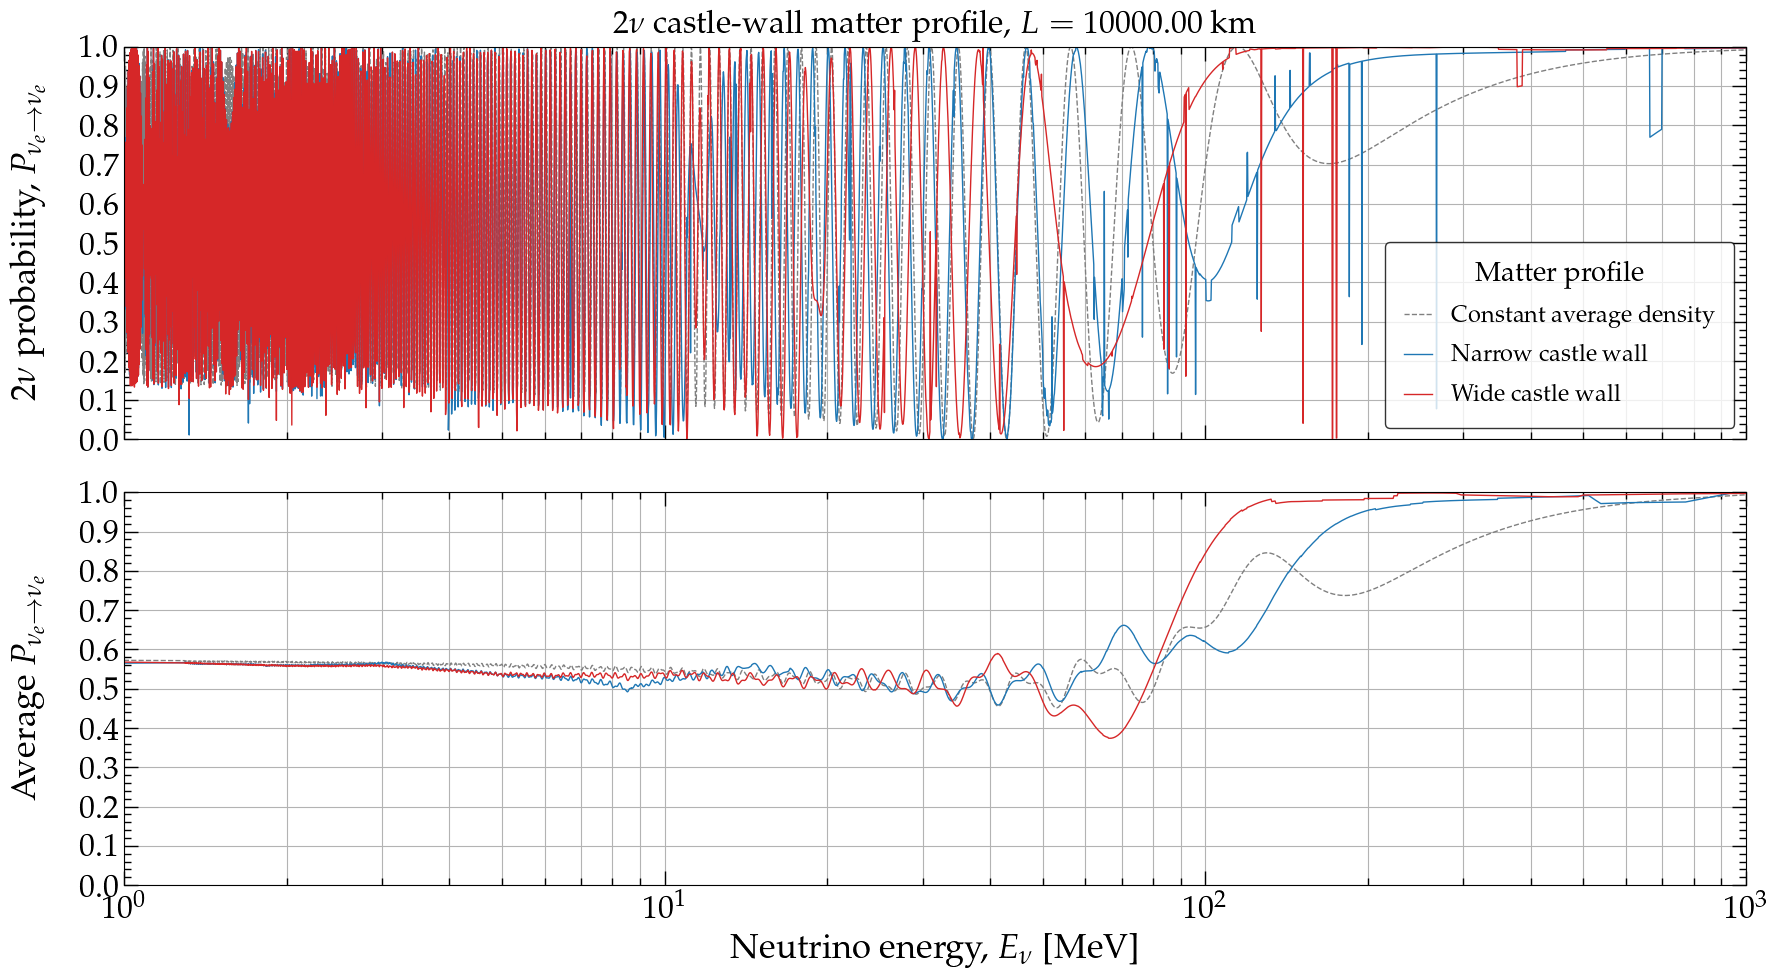

In [25]:
heights = [1.0, 1.0]
widths = [1.0]
gs_kw = dict(height_ratios=heights, width_ratios=widths)
fig, ax = plt.subplots(
    ncols=1, 
    nrows=2, 
    # constrained_layout=True, 
    gridspec_kw=gs_kw, 
    figsize=[18,10])
fig.subplots_adjust(hspace=-0.1, wspace=0)

# Probabilities
ax[0].plot(energies, prob_matt_const_density, lw=1, c='0.5', ls='--', label=r'Constant average density')
ax[0].plot(energies, prob_matt_castle_wall_narrow, lw=1, c='C0', ls='-', label=r'Narrow castle wall')
ax[0].plot(energies, prob_matt_castle_wall_wide, lw=1, c='C3', ls='-', label=r'Wide castle wall')

# Average probabilities
ax[1].plot(energies, sp.signal.savgol_filter(prob_matt_const_density, window_length=301, polyorder=1), 
           lw=1, c='0.5', ls='--')
ax[1].plot(energies, sp.signal.savgol_filter(prob_matt_castle_wall_narrow, window_length=301, polyorder=1), 
           lw=1, c='C0', ls='-')
ax[1].plot(energies, sp.signal.savgol_filter(prob_matt_castle_wall_wide, window_length=301, polyorder=1), 
           lw=1, c='C3', ls='-')

# Legend
ax[0].legend(fontsize=17, frameon=True, loc='lower right', handlelength=1.2, handleheight=0.7, 
          borderpad=0.8, title_fontsize=20, edgecolor='k', labelspacing=0.7, ncol=1, title=r'Matter profile') 

# Formatting
ax[0].set_title(r'$2\nu$~castle-wall matter profile, $L = $~{:.2f}~km'.format(baseline), fontsize=23, pad=10)
ax[1].set_xlabel(r'Neutrino energy, $E_\nu$ [MeV]')
ax[0].set_ylabel(r'$2\nu$~probability,~'+prob_label(nu_i, nu_f), labelpad=25)
ax[1].set_ylabel(r'Average~'+prob_label(nu_i, nu_f), labelpad=25)
for axx in ax:
    axx.set_xlim(energy_min, energy_max)
    axx.set_ylim(0, 1)
    axx.set_xscale('log')
    axx.grid(visible=True, c='0.7', which='both', axis='x')
    axx.grid(visible=True, c='0.7', which='major', axis='y')
    axx.yaxis.set_major_locator(mpl.ticker.MultipleLocator(base=0.10))
    axx.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(base=0.02))
ax[0].xaxis.set_ticklabels([])

# Save plot
plt.tight_layout()
plt.savefig('../fig/prob_2nu_castle_wall_density_vs_energy.pdf', dpi=200)

# 5. Probabilities 2$\nu$: in matter with noisy density profile

## 5.1 General definitions

In [26]:
# Mixing parameters (predefined examples from globaldefs; can change them to anything else)
sth = gd.S12_NO_BF_NUFIT_6_0 # [adim]
Dm2 = gd.D21_NO_BF_NUFIT_6_0 # [eV^2]

In [27]:
# Parameters for the electron number density in the Sun, Eq. (10.62) in Giunti & Kim
num_density_e_center = 10*gd.N_AV/pow(gd.CONV_CM_TO_INV_EV,3.0) # [eV^3]
l_scale = 100.0 # [km]

# Build the noise
np.random.seed(20)
# High-amplitude, more marked noise
npts_noise = 50 # Use more points to make it more finely noised
x_high = np.linspace(0, 1, npts_noise)
noise_sample_high = np.random.normal(loc=1.0, scale=0.3, size=npts_noise) # Increase scale to increase the width of the noise bumps
noise_mask_high_interp = sp.interpolate.make_interp_spline(x_high, noise_sample_high, k=1)
# Low-amplitude, choppier noise
npts_noise = 300 # Use more points to make it more finely noised
x_low = np.linspace(0, 1, npts_noise)
noise_sample_low = np.random.normal(loc=1.0, scale=0.08, size=npts_noise) # Increase scale to increase the width of the noise bumps
noise_mask_low_interp = sp.interpolate.make_interp_spline(x_low, noise_sample_low, k=1)

H_vac_energy_indep = hamiltonians.hamiltonian_2nu_vacuum_energy_independent(sth, Dm2) # Vacuum H without (1/E) [eV^2]

# --------------------------------------------------------------
# In matter, constant density equal to central density
# --------------------------------------------------------------
# The matter density is constant, so this is merely a wrapper.
# [l] = km
VCC_center = matter.VCC_func(0.0, lambda l: num_density_e_center) # [eV]
H_matt_const_density = hamiltonians.hamiltonian_2nu_matter(VCC_center) # [eV]
def H_func_const_density(l, energy):
    return (1/energy)*H_vac_energy_indep+H_matt_const_density

# --------------------------------------------------------------
# In matter, constant density, with noise around central value
# --------------------------------------------------------------
def num_density_e_const_noisy_func(l, num_density_e_const, l_ini, l_fin, noise_model='high-amplitude'):
    l_scaled = (l/gd.CONV_KM_TO_INV_EV-l_ini)/(l_fin-l_ini)
    if noise_model == 'high-amplitude':
        return num_density_e_const*noise_mask_high_interp(l_scaled)
    elif noise_model == 'low-amplitude':
        return num_density_e_const*noise_mask_low_interp(l_scaled)
def VCC_func_const_density_noisy(l, num_density_e_const, l_ini, l_fin, noise_model='high-amplitude'):
    return matter.VCC_func(l, lambda r: num_density_e_const_noisy_func(r, num_density_e_const, l_ini, l_fin, 
                                                                       noise_model=noise_model)) # [eV]
def H_func_const_density_noisy(l, energy, num_density_e_const, l_ini, l_fin, noise_model='high-amplitude'):
    return (1/energy)*H_vac_energy_indep+hamiltonians.hamiltonian_2nu_matter(VCC_func_const_density_noisy(l, num_density_e_const, 
                                                                                                             l_ini, l_fin,
                                                                                                             noise_model=noise_model))
# # --------------------------------------------------------------
# # In matter, exponentially falling density
# # --------------------------------------------------------------
# # [l] = km
# def num_density_e_exp_func(l, num_density_e_center, l_scale):
#     return num_density_e_center*np.exp(-(l/gd.CONV_KM_TO_INV_EV)/l_scale) # [eV^3]
# def VCC_func_exp_density(l, num_density_e_center, l_scale):
#     return matter.VCC_func(l, lambda r: num_density_e_exp_func(r, num_density_e_center, l_scale)) # [eV]
# def H_func_exp_density(l, energy):
#     return (1/energy)*H_vac_energy_indep-hamiltonians.hamiltonian_2nu_matter(VCC_func_exp_density(l, num_density_e_center, l_scale))

# # --------------------------------------------------------------
# # In matter, exponentially falling density, noisy
# # --------------------------------------------------------------
# # [l] = km
# def num_density_e_exp_noisy_func(l, num_density_e_center, l_scale, l_ini, l_fin):
#     l_scaled = (l/gd.CONV_KM_TO_INV_EV-l_ini)/(l_fin-l_ini)
#     return num_density_e_exp_func(l, num_density_e_center, l_scale)*noise_mask_interp(l_scaled)
# def VCC_func_exp_density_noisy(l, num_density_e_center, l_scale, l_ini, l_fin):
#     return matter.VCC_func(l, lambda r: num_density_e_exp_noisy_func(r, num_density_e_center, l_scale, l_ini, l_fin)) # [eV]
# def H_func_exp_density_noisy(l, energy, num_density_e_center, l_scale, l_ini, l_fin):
#     return (1/energy)*H_vac_energy_indep \
#         - hamiltonians.hamiltonian_2nu_matter(VCC_func_exp_density_noisy(l, num_density_e_center, l_scale, l_ini, l_fin))

## 5.2 Probabilities vs. distance

### Generate probabilities

In [28]:
# Baselines
l_ini, l_fin = 1.e2, 1.e5 # [km]
l_npts = 6000 
distances = np.logspace(np.log10(l_ini), np.log10(l_fin), l_npts) # [km]

# Compute probability vs. baseline
# osc_prob and osc_prob_2nu_vacuum_std return a 2x2 NumPy array with the probabilities: [[Pee, Pem], [Pme, Pmm]]
nu_i, nu_f = gd.NUE, gd.NUE # Initial and final flavors; can also choose NUMU or NUTAU
energy = 50.*gd.UNIT_MEV # [eV] #10

#--------------------------------------------------------------
# In matter, constant density
# --------------------------------------------------------------
prob_matt_const_density = np.array([oscprob.osc_prob(lambda l: H_func_const_density(l, energy), 
                                                     0, l*gd.CONV_KM_TO_INV_EV, 
                                                     n_slabs=1, n_tpts_per_slab=10, magnus_exp_order=1)[nu_i][nu_f] for l in distances])

# --------------------------------------------------------------
# In matter, constant density, high-amplitude noise
# --------------------------------------------------------------
prob_matt_const_density_noisy_high_amplitude = np.array([oscprob.osc_prob(lambda l: H_func_const_density_noisy(l, energy, 
                                                                                                            num_density_e_center, 
                                                                                                            l_ini, l_fin,
                                                                                                            noise_model='high-amplitude'), 
                                                     0, l*gd.CONV_KM_TO_INV_EV, 
                                                     n_slabs=150, n_tpts_per_slab=100, magnus_exp_order=3, n_jobs=10)[nu_i][nu_f] \
                                          for l in distances]) 

# --------------------------------------------------------------
# In matter, constant density, low-amplitude noise
# --------------------------------------------------------------
prob_matt_const_density_noisy_low_amplitude = np.array([oscprob.osc_prob(lambda l: H_func_const_density_noisy(l, energy, 
                                                                                                            num_density_e_center, 
                                                                                                            l_ini, l_fin,
                                                                                                            noise_model='low-amplitude'), 
                                                     0, l*gd.CONV_KM_TO_INV_EV, 
                                                     n_slabs=150, n_tpts_per_slab=100, magnus_exp_order=3, n_jobs=10)[nu_i][nu_f] \
                                          for l in distances]) 

# # --------------------------------------------------------------
# # In matter, exponentially falling density
# # --------------------------------------------------------------
# prob_matt_exp_density = np.array([oscprob.osc_prob(lambda l: H_func_exp_density(l, energy), 
#                                                    0, l*gd.CONV_KM_TO_INV_EV, 
#                                                    n_slabs=1, n_tpts_per_slab=10, magnus_exp_order=1)[nu_i][nu_f] for l in distances])

/home/mbustamante/Research/magnus/src/magnus/magnus.py:1040: MagnusConvergenceWarning: at least one time slab is too wide for guaranteed convergence of the Magnus series (||Omega||_2 >= pi); raising the expansion order will not help there -- more (narrower) slabs are needed. If a target tolerance (rtol/atol) was requested, the adaptive refinement narrows the slabs automatically and this warning can be ignored. Shown once per session.
  return evolution_operators_from_samples(At, widths, order,


### Plot probabilities

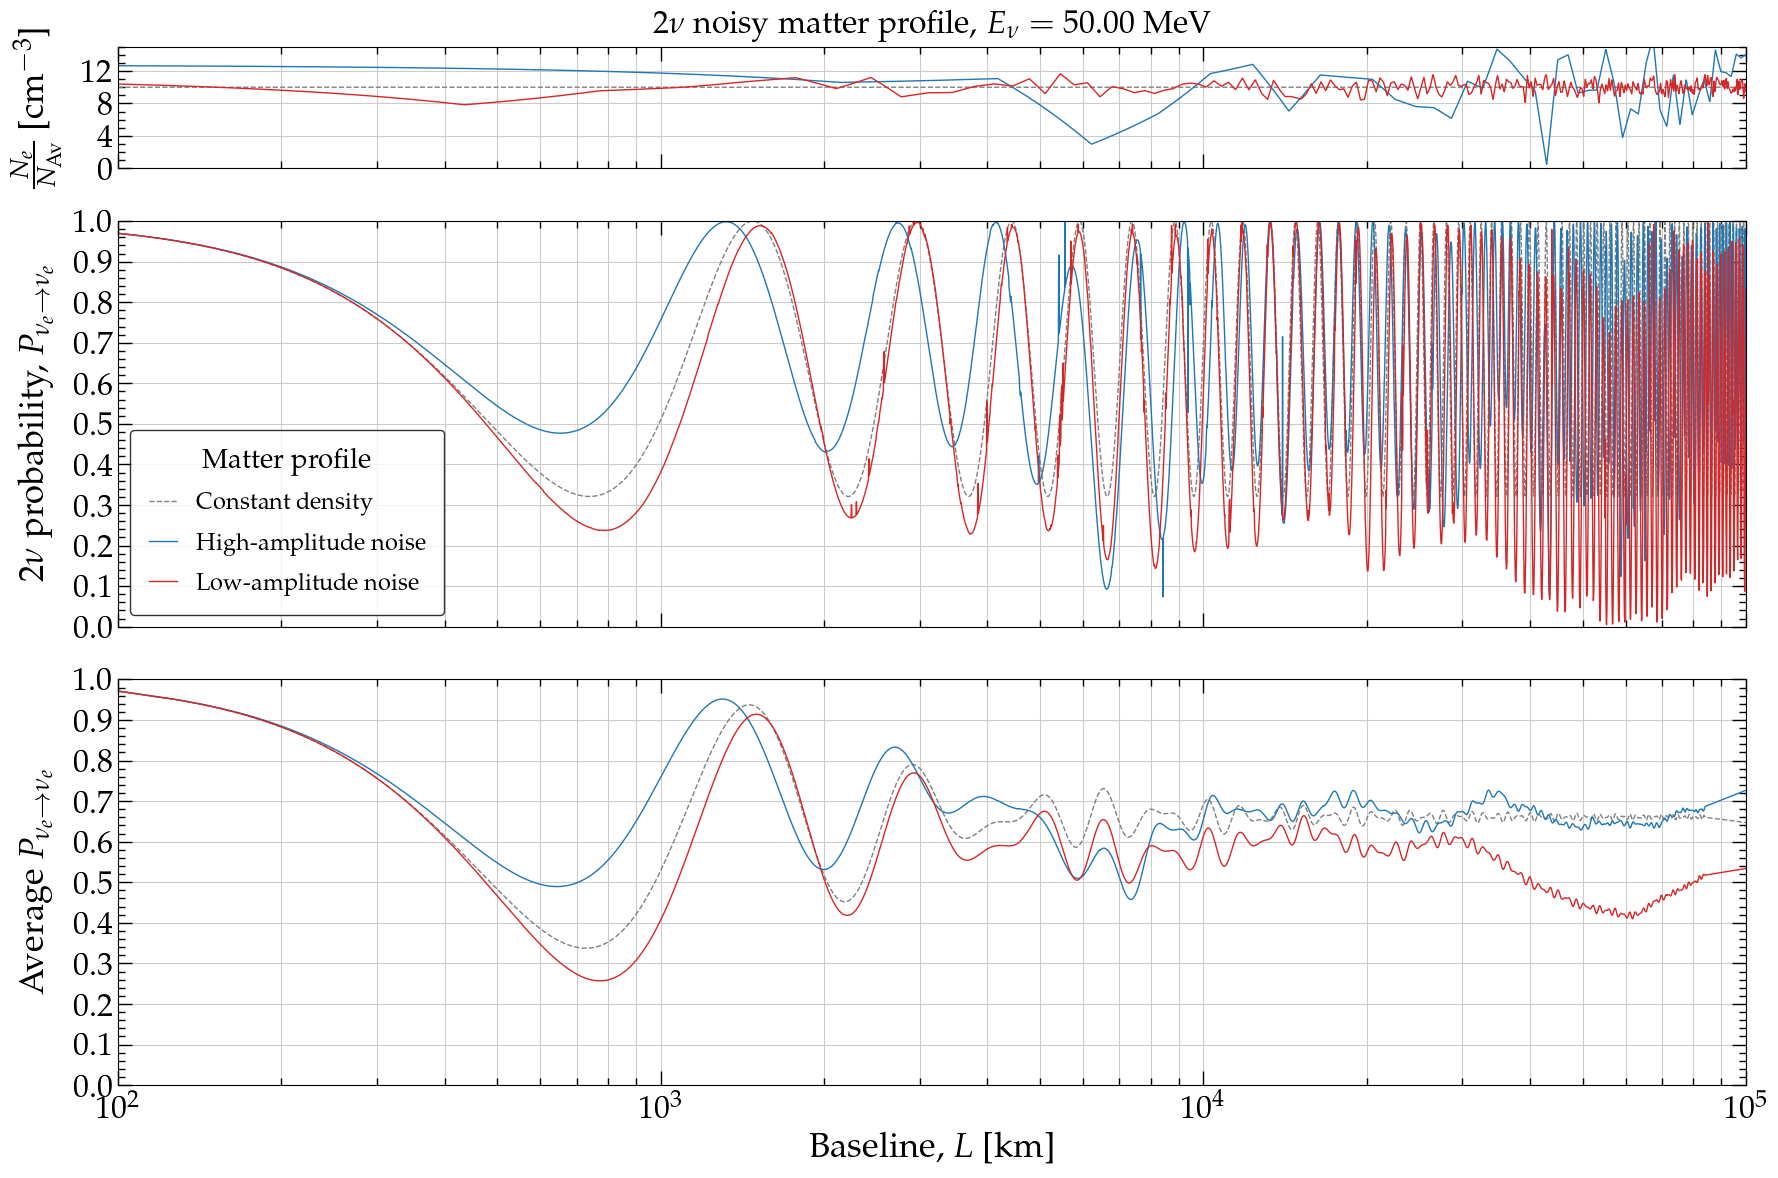

In [29]:
heights = [0.3, 1.0, 1.0]
widths = [1.0]
gs_kw = dict(height_ratios=heights, width_ratios=widths)
fig, ax = plt.subplots(
    ncols=1, 
    nrows=3, 
    # constrained_layout=True, 
    gridspec_kw=gs_kw, 
    figsize=[18,12])
fig.subplots_adjust(hspace=0.05, wspace=0.05)

# Density profiles
ax[0].plot(distances, [num_density_e_center/(gd.N_AV/pow(gd.CONV_CM_TO_INV_EV,3.0)) for l in distances], lw=1, ls='--', c='0.5')
ax[0].plot(distances, [num_density_e_const_noisy_func(l*gd.CONV_KM_TO_INV_EV, num_density_e_center, l_ini, l_fin,
                                                      noise_model='high-amplitude') \
                       /(gd.N_AV/pow(gd.CONV_CM_TO_INV_EV,3.0)) for l in distances], lw=1, ls='-', c='C0')
ax[0].plot(distances, [num_density_e_const_noisy_func(l*gd.CONV_KM_TO_INV_EV, num_density_e_center, l_ini, l_fin,
                                                      noise_model='low-amplitude') \
                       /(gd.N_AV/pow(gd.CONV_CM_TO_INV_EV,3.0)) for l in distances], lw=1, ls='-', c='C3')

# Probabilities
ax[1].plot(distances, prob_matt_const_density, lw=1, c='0.5', ls='--', label=r'Constant density')
ax[1].plot(distances, prob_matt_const_density_noisy_high_amplitude, lw=1, c='C0', ls='-', label=r'High-amplitude noise')
ax[1].plot(distances, prob_matt_const_density_noisy_low_amplitude, lw=1, c='C3', ls='-', label=r'Low-amplitude noise')

# Average probabilities
ax[2].plot(distances, sp.signal.savgol_filter(prob_matt_const_density, window_length=301, polyorder=1), 
           lw=1, c='0.5', ls='--')
ax[2].plot(distances, sp.signal.savgol_filter(prob_matt_const_density_noisy_high_amplitude, window_length=301, polyorder=1), 
           lw=1, c='C0', ls='-')
ax[2].plot(distances, sp.signal.savgol_filter(prob_matt_const_density_noisy_low_amplitude, window_length=301, polyorder=1), 
           lw=1, c='C3', ls='-')


# Legend
ax[1].legend(fontsize=17, frameon=True, loc='lower left', handlelength=1.2, handleheight=0.7,
             borderpad=0.8, title_fontsize=20, edgecolor='k', labelspacing=0.7, ncol=1, title=r'Matter profile')

# Formatting
for axx in ax:
    axx.set_xscale('log')
    axx.set_xlim(l_ini, l_fin)
    axx.grid(visible=True, c='0.8', which='both', axis='x')
    axx.grid(visible=True, c='0.8', which='major', axis='y')
ax[0].set_ylabel(r'$\frac{N_e}{N_{\rm Av}}$~[cm$^{-3}$]', labelpad=15)
ax[0].set_ylim(0, 15) #13
ax[0].yaxis.set_major_locator(mpl.ticker.MultipleLocator(base=4))
ax[0].yaxis.set_minor_locator(mpl.ticker.MultipleLocator(base=1))
ax[0].xaxis.set_ticklabels([])
ax[0].set_title(r'$2\nu$~noisy matter profile, $E_\nu = $~{:.2f}~MeV'.format(energy/gd.UNIT_MEV), fontsize=23, pad=10)
ax[1].set_ylabel(r'$2\nu$~probability,~'+prob_label(nu_i, nu_f), labelpad=15)
ax[1].set_ylim(0, 1)
ax[1].yaxis.set_major_locator(mpl.ticker.MultipleLocator(base=0.10))
ax[1].yaxis.set_minor_locator(mpl.ticker.MultipleLocator(base=0.02))
ax[1].xaxis.set_ticklabels([])
ax[2].set_ylim(0, 1)
ax[2].yaxis.set_major_locator(mpl.ticker.MultipleLocator(base=0.10))
ax[2].yaxis.set_minor_locator(mpl.ticker.MultipleLocator(base=0.02))
ax[2].set_xlabel(r'Baseline, $L$~[km]')
ax[2].set_ylabel(r'Average~'+prob_label(nu_i, nu_f), labelpad=15)

# Save plot
plt.tight_layout()
plt.savefig('../fig/prob_2nu_varying_density_noisy_vs_baseline.pdf', dpi=200)

## 5.3 Probabilities vs. energy

### Generate probabilities

In [30]:
# Energies
energy_min, energy_max = 1.e1, 1.e2 # [MeV]
energy_npts = 6000
energies = np.logspace(np.log10(energy_min), np.log10(energy_max), energy_npts) # [MeV]

# Compute probability vs. energy
# osc_prob and osc_prob_2nu_vacuum_std return a 2x2 NumPy array with the probabilities: [[Pee, Pem], [Pme, Pmm]]
nu_i, nu_f = gd.NUE, gd.NUE # Initial and final flavors; can also choose NUMU or NUTAU
baseline = 1.e5 # [km]

#--------------------------------------------------------------
# In matter, constant density
# --------------------------------------------------------------
prob_matt_const_density = np.array([oscprob.osc_prob(lambda l: H_func_const_density(l, enu*gd.UNIT_MEV),
                                                     0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                     n_slabs=1, n_tpts_per_slab=10, magnus_exp_order=1)[nu_i][nu_f] for enu in energies])

# --------------------------------------------------------------
# In matter, constant density, high-amplitude noise
# --------------------------------------------------------------
prob_matt_const_density_noisy_high_amplitude = np.array([oscprob.osc_prob(lambda l: H_func_const_density_noisy(l, enu*gd.UNIT_MEV,
                                                                                                            num_density_e_center, 
                                                                                                            l_ini, l_fin,
                                                                                                            noise_model='high-amplitude'), 
                                                     0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                     n_slabs=150, n_tpts_per_slab=100, magnus_exp_order=3, n_jobs=10)[nu_i][nu_f] \
                                          for enu in energies]) 

# --------------------------------------------------------------
# In matter, constant density, low-amplitude noise
# --------------------------------------------------------------
prob_matt_const_density_noisy_low_amplitude = np.array([oscprob.osc_prob(lambda l: H_func_const_density_noisy(l, enu*gd.UNIT_MEV,
                                                                                                            num_density_e_center,
                                                                                                            l_ini, l_fin,
                                                                                                            noise_model='low-amplitude'), 
                                                     0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                     n_slabs=150, n_tpts_per_slab=100, magnus_exp_order=3, n_jobs=10)[nu_i][nu_f] \
                                          for enu in energies]) 

/home/mbustamante/Research/magnus/src/magnus/magnus.py:1040: MagnusConvergenceWarning: at least one time slab is too wide for guaranteed convergence of the Magnus series (||Omega||_2 >= pi); raising the expansion order will not help there -- more (narrower) slabs are needed. If a target tolerance (rtol/atol) was requested, the adaptive refinement narrows the slabs automatically and this warning can be ignored. Shown once per session.
  return evolution_operators_from_samples(At, widths, order,


### Plot probabilities

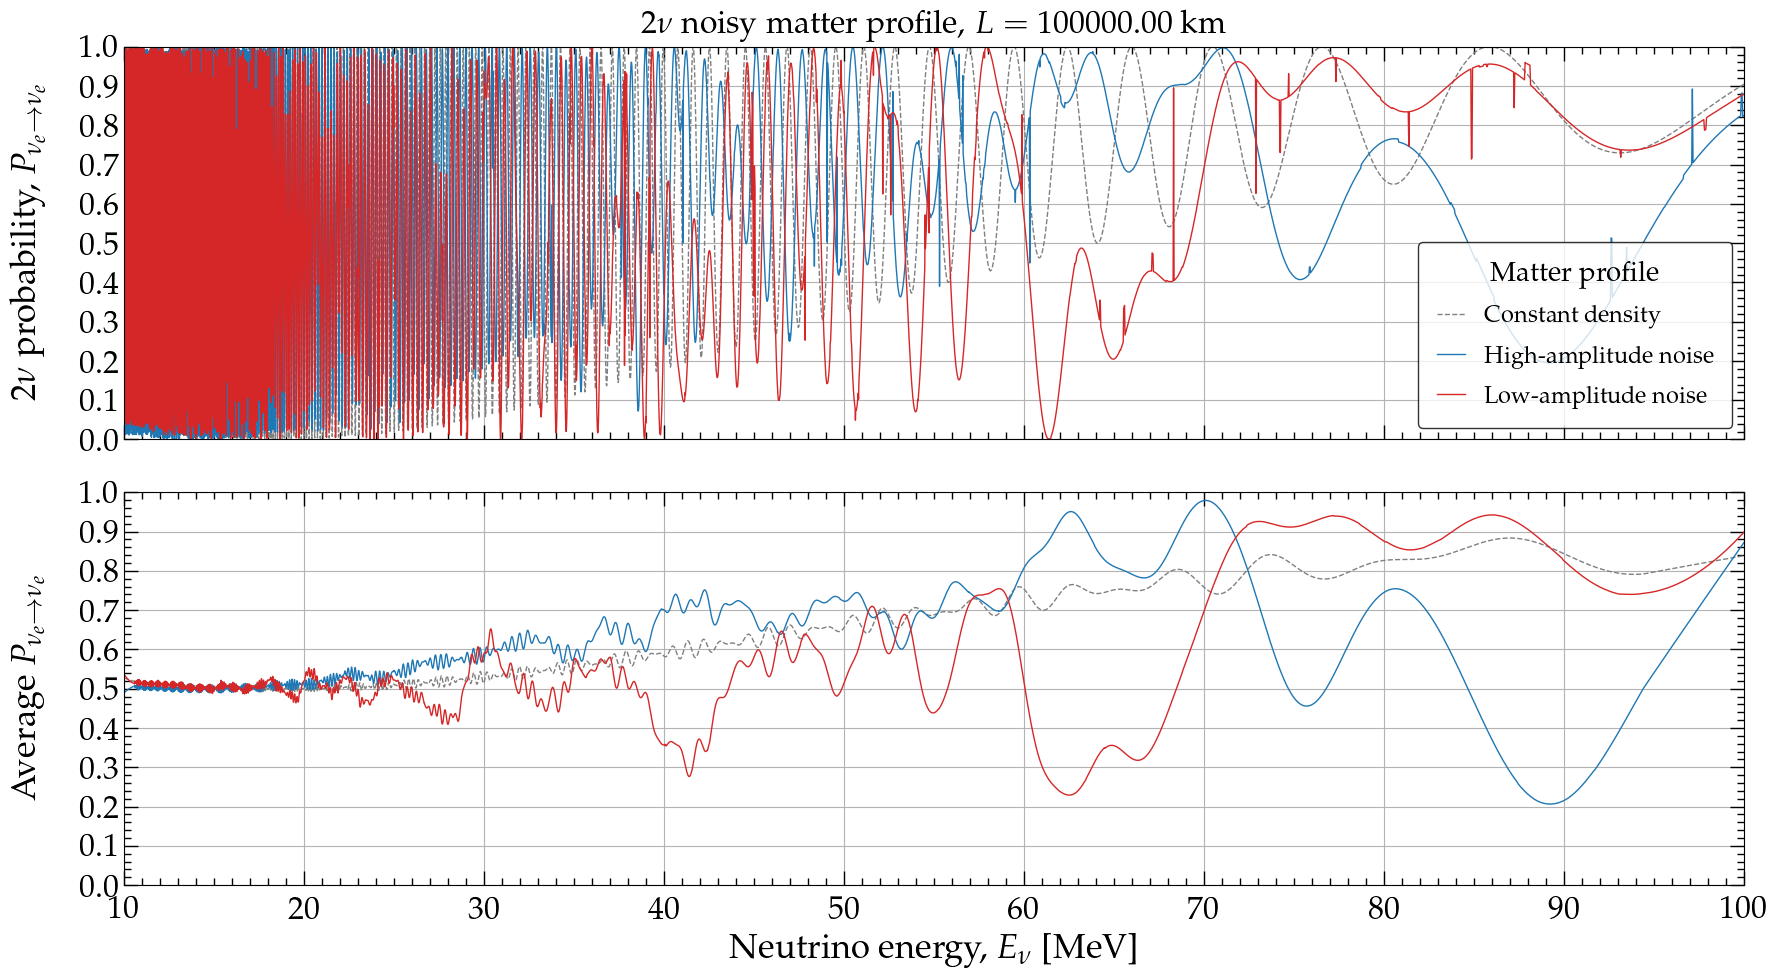

In [31]:
heights = [1.0, 1.0]
widths = [1.0]
gs_kw = dict(height_ratios=heights, width_ratios=widths)
fig, ax = plt.subplots(
    ncols=1, 
    nrows=2, 
    # constrained_layout=True, 
    gridspec_kw=gs_kw, 
    figsize=[18,10])
fig.subplots_adjust(hspace=-0.1, wspace=0)

# Probabilities
ax[0].plot(energies, prob_matt_const_density, lw=1, c='0.5', ls='--', label=r'Constant density')
ax[0].plot(energies, prob_matt_const_density_noisy_high_amplitude, lw=1, c='C0', ls='-', label=r'High-amplitude noise')
ax[0].plot(energies, prob_matt_const_density_noisy_low_amplitude, lw=1, c='C3', ls='-', label=r'Low-amplitude noise')

# Average probabilities
ax[1].plot(energies, sp.signal.savgol_filter(prob_matt_const_density, window_length=301, polyorder=1), 
           lw=1, c='0.5', ls='--')
ax[1].plot(energies, sp.signal.savgol_filter(prob_matt_const_density_noisy_high_amplitude, window_length=301, polyorder=2), 
           lw=1, c='C0', ls='-')
ax[1].plot(energies, sp.signal.savgol_filter(prob_matt_const_density_noisy_low_amplitude, window_length=301, polyorder=2), 
           lw=1, c='C3', ls='-')

# Legend
ax[0].legend(fontsize=17, frameon=True, loc='lower right', handlelength=1.2, handleheight=0.7, 
          borderpad=0.8, title_fontsize=20, edgecolor='k', labelspacing=0.7, ncol=1, title=r'Matter profile') 

# Formatting
ax[0].set_title(r'$2\nu$~noisy matter profile, $L = $~{:.2f}~km'.format(baseline), fontsize=23, pad=10)
ax[1].set_xlabel(r'Neutrino energy, $E_\nu$ [MeV]')
ax[0].set_ylabel(r'$2\nu$~probability,~'+prob_label(nu_i, nu_f), labelpad=25)
ax[1].set_ylabel(r'Average~'+prob_label(nu_i, nu_f), labelpad=25)
ax[0].xaxis.set_ticklabels([])
for axx in ax:
    axx.set_xlim(energy_min, energy_max)
    axx.set_ylim(0, 1)
    # axx.set_xscale('log')
    axx.grid(visible=True, c='0.7')
    axx.xaxis.set_major_locator(mpl.ticker.MultipleLocator(base=10))
    axx.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(base=1))
    axx.yaxis.set_major_locator(mpl.ticker.MultipleLocator(base=0.10))
    axx.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(base=0.02))

# Save plot
plt.tight_layout()
plt.savefig('../fig/prob_2nu_varying_density_noisy_vs_energy.pdf', dpi=200)

# 6. Probabilities 2$\nu$: in the Earth

## 6.1 General definitions

In [32]:
# Mixing parameters (predefined examples from globaldefs; can change them to anything else)
sth = gd.S12_NO_BF_NUFIT_6_0 # [adim]
Dm2 = gd.D21_NO_BF_NUFIT_6_0 # [eV^2]

In [33]:
def num_density_e_func_prem(r): 
    return matter.num_density_e_func(r, earth.density_matter_func_prem, electron_fraction=0.5, density_matter_is_in_g_per_cm3=True) # [eV^{-3}]

def VCC_func_prem(r):
    return matter.VCC_func(r, num_density_e_func_prem) # [eV]

H_vac_energy_indep = hamiltonians.hamiltonian_2nu_vacuum_energy_independent(sth, Dm2) # Vacuum H without (1/E) [eV^2]

# [l] = km
def H_func_prem(costhz, l, energy):
    # Given a direction (costhz) and a depth (l), compute the radial distance from the center of the Earth (r)
    r = earth.earth_radial_distance_from_depth(costhz, l/gd.CONV_KM_TO_INV_EV) 
    return (1/energy)*H_vac_energy_indep+hamiltonians.hamiltonian_2nu_matter(VCC_func_prem(r))

# Test values of the zenith angle, cos(theta_z), to plot, with theta_z = 0 normal to the surface of the Earth, at the position of the
# detector.  All of the direction are upgoing.
costhz_val = [-0.1, -0.5, -1.0]

# Maximum baselines inside the Earth
l_max_val = [earth.distance_traveled_inside_earth(costhz) for costhz in costhz_val] # [km]

## 6.2 Probabilities vs. distance

### Generate probabilities

In [34]:
# Compute probability vs. baseline
# osc_prob and osc_prob_2nu_vacuum_std return a 2x2 NumPy array with the probabilities: [[Pee, Pem], [Pme, Pmm]]

nu_i, nu_f = gd.NUE, gd.NUE # Initial and final flavors; can also choose NUMU or NUTAU
energy = 20.*gd.UNIT_MEV # [eV] #10

l_min = 1.e2 # [km]

# Generate probabilities for the different directions
distances_val, prob_val = [], []
l_npts = 3000
for i in range(len(costhz_val)):
    print("costhz = "+str(costhz_val[i]))
    distances = np.logspace(np.log10(l_min), np.log10(l_max_val[i]), l_npts) # [km]
    distances_val.append(distances)
    prob = np.array([oscprob.osc_prob(lambda l: H_func_prem(costhz_val[i], l, energy), 0, l*gd.CONV_KM_TO_INV_EV, 
                                      n_slabs=100, n_tpts_per_slab=20, magnus_exp_order=3, n_jobs=10)[nu_i][nu_f] for l in distances]) 
    prob_val.append(prob)

costhz = -0.1


/home/mbustamante/Research/magnus/src/magnus/magnus.py:1040: MagnusConvergenceWarning: at least one time slab is too wide for guaranteed convergence of the Magnus series (||Omega||_2 >= pi); raising the expansion order will not help there -- more (narrower) slabs are needed. If a target tolerance (rtol/atol) was requested, the adaptive refinement narrows the slabs automatically and this warning can be ignored. Shown once per session.
  return evolution_operators_from_samples(At, widths, order,


costhz = -0.5


costhz = -1.0


### Plot probabilities

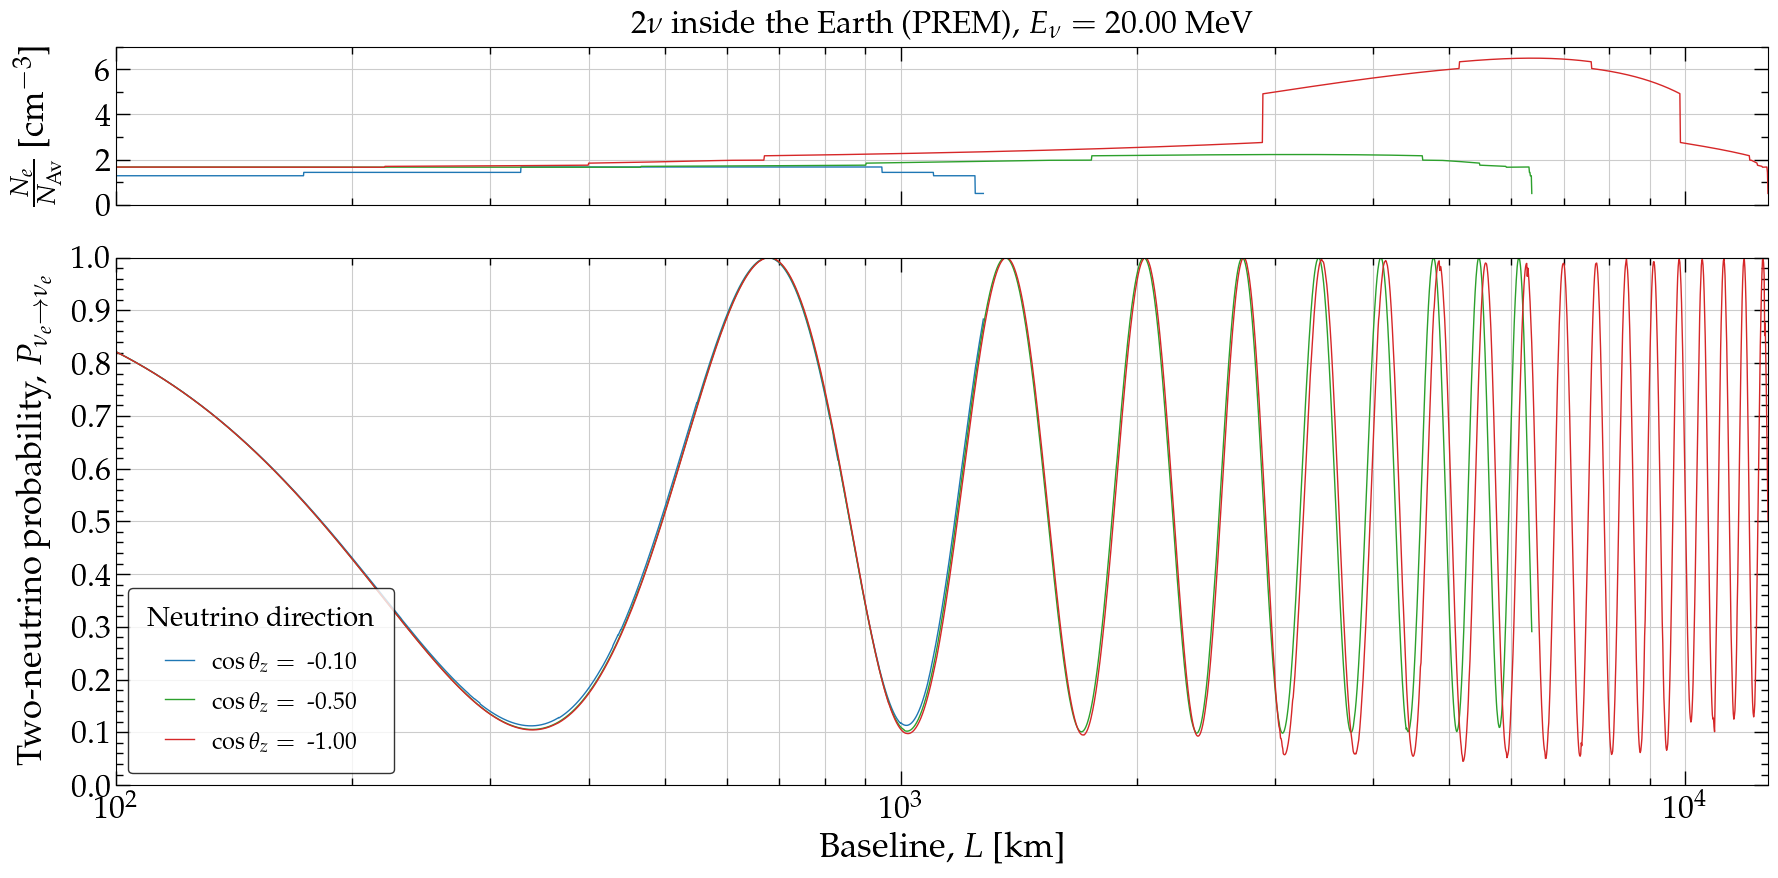

In [35]:
heights = [0.3, 1.0]
widths = [1.0]
gs_kw = dict(height_ratios=heights, width_ratios=widths)
fig, ax = plt.subplots(
    ncols=1, 
    nrows=2, 
    # constrained_layout=True, 
    gridspec_kw=gs_kw, 
    figsize=[18,9])
fig.subplots_adjust(hspace=0.05, wspace=0.05)

lc = ['C0', 'C2', 'C3']
ls = ['-', '-', '-']

# Probabilities
for i in range(len(costhz_val)):
    num_density_e = np.array([num_density_e_func_prem(earth.earth_radial_distance_from_depth(costhz_val[i], l)) \
                     for l in distances_val[i]])
    num_density_e = 1.0/(gd.N_AV/pow(gd.CONV_CM_TO_INV_EV,3.0)) * num_density_e
    ax[0].plot(distances_val[i], num_density_e, lw=1, ls=ls[i], c=lc[i])
    ax[1].plot(distances_val[i], prob_val[i], lw=1, c=lc[i], ls=ls[i], label=r'$\cos \theta_z = $~~{:.2f}'.format(costhz_val[i]))

# Legend
ax[1].legend(fontsize=17, frameon=True, loc='lower left', handlelength=1.2, handleheight=0.7,
             borderpad=0.8, title_fontsize=20, edgecolor='k', labelspacing=0.7, ncol=1, title=r'Neutrino direction')

# Formatting
for axx in ax:
    axx.set_xscale('log')
    axx.set_xlim(l_min, max(l_max_val))
    axx.grid(visible=True, c='0.8', which='both', axis='x')
    axx.grid(visible=True, c='0.8', which='major', axis='y')
ax[0].set_ylabel(r'$\frac{N_e}{N_{\rm Av}}$~[cm$^{-3}$]', labelpad=25)
ax[0].set_ylim(0, 7)
ax[0].yaxis.set_major_locator(mpl.ticker.MultipleLocator(base=2))
ax[0].yaxis.set_minor_locator(mpl.ticker.MultipleLocator(base=1))
ax[0].xaxis.set_ticklabels([])
ax[0].set_title(r'$2\nu$~inside the Earth (PREM), $E_\nu = $~{:.2f}~MeV'.format(energy/gd.UNIT_MEV), fontsize=23, pad=10)
ax[1].set_ylabel(r'Two-neutrino probability,~'+prob_label(nu_i, nu_f), labelpad=15)
ax[1].set_ylim(0, 1)
ax[1].yaxis.set_major_locator(mpl.ticker.MultipleLocator(base=0.10))
ax[1].yaxis.set_minor_locator(mpl.ticker.MultipleLocator(base=0.02))
ax[1].set_xlabel(r'Baseline, $L$~[km]')

# Save plot
plt.tight_layout()
plt.savefig('../fig/prob_2nu_earth_vs_baseline.pdf', dpi=200)

## 6.3 Probabilities vs. energy

### Generate probabilities

In [36]:
# Energies
energy_min, energy_max = 1.e1, 1.e2 # [MeV]
energy_npts = 3000
energies = np.logspace(np.log10(energy_min), np.log10(energy_max), energy_npts) # [MeV]

# Compute probability vs. energy
# osc_prob and osc_prob_2nu_vacuum_std return a 2x2 NumPy array with the probabilities: [[Pee, Pem], [Pme, Pmm]]
nu_i, nu_f = gd.NUE, gd.NUE # Initial and final flavors; can also choose NUMU or NUTAU

# Generate probabilities for the different directions
prob_val = []
for i in range(len(costhz_val)):
    print("costhz = "+str(costhz_val[i]))
    prob = np.array([oscprob.osc_prob(lambda l: H_func_prem(costhz_val[i], l, enu*gd.UNIT_MEV), 
                                      0, l_max_val[i]*gd.CONV_KM_TO_INV_EV, 
                                      n_slabs=100, n_tpts_per_slab=20, magnus_exp_order=3, n_jobs=10)[nu_i][nu_f] for enu in energies]) 
    prob_val.append(prob)

costhz = -0.1


/home/mbustamante/Research/magnus/src/magnus/magnus.py:1040: MagnusConvergenceWarning: at least one time slab is too wide for guaranteed convergence of the Magnus series (||Omega||_2 >= pi); raising the expansion order will not help there -- more (narrower) slabs are needed. If a target tolerance (rtol/atol) was requested, the adaptive refinement narrows the slabs automatically and this warning can be ignored. Shown once per session.
  return evolution_operators_from_samples(At, widths, order,


costhz = -0.5


costhz = -1.0


### Plot probabilities

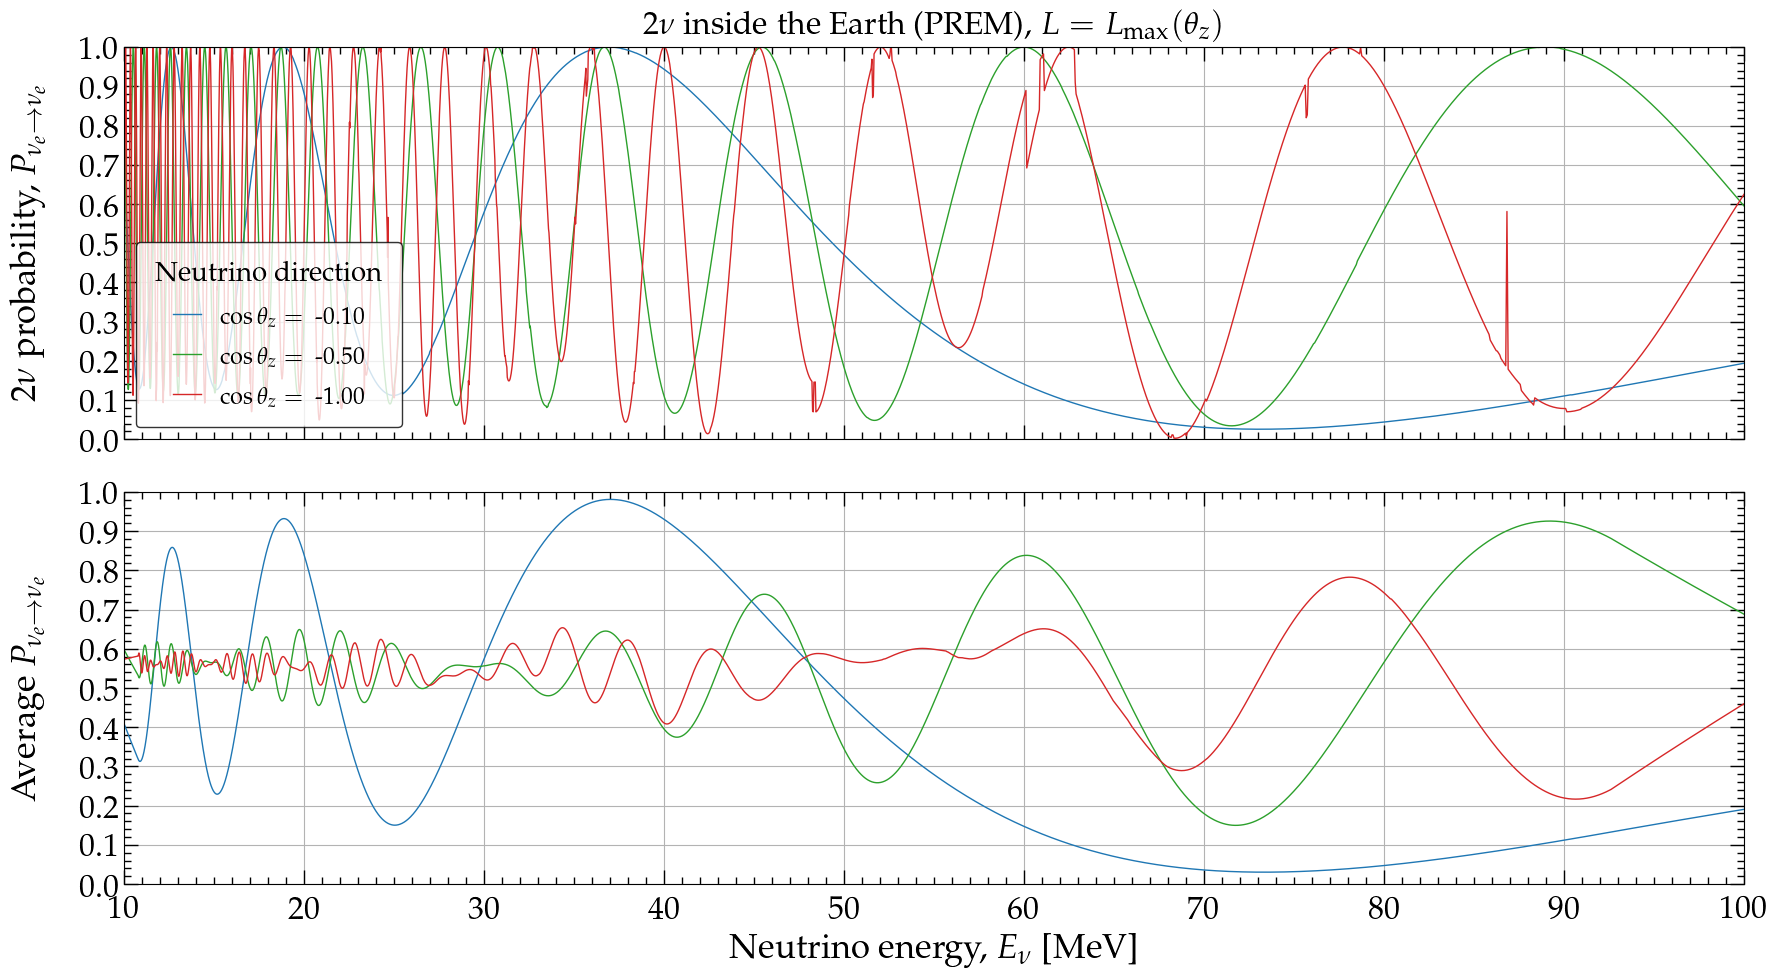

In [37]:
heights = [1.0, 1.0]
widths = [1.0]
gs_kw = dict(height_ratios=heights, width_ratios=widths)
fig, ax = plt.subplots(
    ncols=1, 
    nrows=2, 
    # constrained_layout=True, 
    gridspec_kw=gs_kw, 
    figsize=[18,10])
fig.subplots_adjust(hspace=-0.1, wspace=0)

lc = ['C0', 'C2', 'C3']
ls = ['-', '-', '-']

# Probabilities
for i in range(len(costhz_val)):
    ax[0].plot(energies, prob_val[i], lw=1, c=lc[i], ls=ls[i], label=r'$\cos \theta_z = $~~{:.2f}'.format(costhz_val[i]))
    ax[1].plot(energies, sp.signal.savgol_filter(prob_val[i], window_length=201, polyorder=1), lw=1, c=lc[i], ls=ls[i])

# Average probabilities
# ax[1].plot(energies, sp.signal.savgol_filter(prob_matt_const_density, window_length=301, polyorder=1), 
#            lw=1, c='0.5', ls='--')
# ax[1].plot(energies, sp.signal.savgol_filter(prob_matt_const_density_noisy_high_amplitude, window_length=301, polyorder=2), 
#            lw=1, c='C0', ls='-')
# ax[1].plot(energies, sp.signal.savgol_filter(prob_matt_const_density_noisy_low_amplitude, window_length=301, polyorder=2), 
#            lw=1, c='C3', ls='-')

# Legend
ax[0].legend(fontsize=17, frameon=True, loc='lower left', handlelength=1.2, handleheight=0.7,
             borderpad=0.8, title_fontsize=20, edgecolor='k', labelspacing=0.7, ncol=1, title=r'Neutrino direction')

# Formatting
ax[0].set_title(r'$2\nu$~inside the Earth (PREM), $L = L_{\rm max}(\theta_z)$', fontsize=23, pad=10)
ax[1].set_xlabel(r'Neutrino energy, $E_\nu$ [MeV]')
ax[0].set_ylabel(r'$2\nu$~probability,~'+prob_label(nu_i, nu_f), labelpad=25)
ax[1].set_ylabel(r'Average~'+prob_label(nu_i, nu_f), labelpad=25)
ax[0].xaxis.set_ticklabels([])
for axx in ax:
    axx.set_xlim(energy_min, energy_max)
    axx.set_ylim(0, 1)
    # axx.set_xscale('log')
    axx.grid(visible=True, c='0.7')
    axx.xaxis.set_major_locator(mpl.ticker.MultipleLocator(base=10))
    axx.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(base=1))
    axx.yaxis.set_major_locator(mpl.ticker.MultipleLocator(base=0.10))
    axx.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(base=0.02))

# Save plot
plt.tight_layout()
plt.savefig('../fig/prob_2nu_earth_vs_energy.pdf', dpi=200)

# 7. Probabilities 2$\nu$: in the Sun

## 7.1 General definitions

In [38]:
# Mixing parameters (predefined examples from globaldefs; can change them to anything else)
sth = gd.S12_NO_BF_NUFIT_6_0 # [adim]
Dm2 = gd.D21_NO_BF_NUFIT_6_0 # [eV^2]

In [39]:
# Parameters for the electron number density in the Sun, Eq. (10.62) in Giunti & Kim
num_density_e_center_sun = 245*gd.N_AV/pow(gd.CONV_CM_TO_INV_EV,3.0) # [eV^3]
l_scale_sun = gd.SUN_RADIUS/10.54 # [km]

# Potential assuming constant density: the matter density is constant, so this is merely a wrapper.
# [l] = km
def num_density_e_sun_const_func(l):
    return num_density_e_center_sun # [eV^3]
def VCC_func_const_density_sun(l):
    return matter.VCC_func(l, num_density_e_sun_const_func) # [eV]

# Potential assuming exponentially decreasing density
# [l] = km
def num_density_e_sun_exp_func(l):
    return num_density_e_center_sun*np.exp(-(l/gd.CONV_KM_TO_INV_EV)/l_scale_sun) # [eV^3]
def VCC_func_exp_sun(l):
    return matter.VCC_func(l, num_density_e_sun_exp_func) # [eV]

## 7.2 Probabilities vs. distance

### Generate probabilities

In [40]:
# Baselines
l_ini, l_fin = 1.e-3, 1.0 # l/SUN_RADIUS
l_npts = 1000
distances = np.logspace(np.log10(l_ini), np.log10(l_fin), l_npts) # l/SUN_RADIUS

# Compute probability vs. baseline
# osc_prob and osc_prob_2nu_vacuum_std return a 2x2 NumPy array with the probabilities: [[Pee, Pem], [Pme, Pmm]]
nu_i, nu_f = gd.NUE, gd.NUE # Initial and final flavors; can also choose NUMU or NUTAU
energy = 5.0*gd.UNIT_MEV # [eV]

# --------------------------------------------------------------
# In matter, constant density equal to central solar density
# --------------------------------------------------------------
H_func_const_density = lambda l: hamiltonians.hamiltonian_2nu_vacuum(energy, sth, Dm2) \
                                      + hamiltonians.hamiltonian_2nu_matter(VCC_func_const_density_sun(l))
prob_matt_const_density = np.array([oscprob.osc_prob(H_func_const_density, 
                                                     0, l*gd.SUN_RADIUS*gd.CONV_KM_TO_INV_EV, 
                                                     n_slabs=1, n_tpts_per_slab=10, magnus_exp_order=1)[nu_i][nu_f] for l in distances])

# --------------------------------------------------------------
# In matter, solar matter density profile
# --------------------------------------------------------------
H_func_exp_density = lambda l: hamiltonians.hamiltonian_2nu_vacuum(energy, sth, Dm2) \
                                      + hamiltonians.hamiltonian_2nu_matter(VCC_func_exp_sun(l))
# H_func_exp_density = lambda l: hamiltonians.hamiltonian_2nu_vacuum(energy, sth, Dm2) \
                                      # + hamiltonians.hamiltonian_2nu_matter(-VCC_func_exp_sun(l))
prob_matt_exp_density = np.array([oscprob.osc_prob(H_func_exp_density, 
                                                   0, l*gd.SUN_RADIUS*gd.CONV_KM_TO_INV_EV, 
                                                   n_slabs=200, n_tpts_per_slab=100, magnus_exp_order=3, n_jobs=8)[nu_i][nu_f] \
                                  for l in distances])

# --------------------------------------------------------------
# In vacuum
# --------------------------------------------------------------
# Using Magnus expansion
H_func = lambda l: hamiltonians.hamiltonian_2nu_vacuum(energy, sth, Dm2)
prob_vac = np.array([oscprob.osc_prob(H_func,
                                      0.0, l*gd.SUN_RADIUS*gd.CONV_KM_TO_INV_EV, 
                                      n_slabs=1, n_tpts_per_slab=10, magnus_exp_order=1)[nu_i][nu_f] for l in distances])
# # Using standard formula
# prob_std = np.array([oscprobstd.osc_prob_2nu_vacuum_std(sth, Dm2, energy, l*gd.CONV_KM_TO_INV_EV)[nu_i][nu_f] for l in distances])

/home/mbustamante/Research/magnus/src/magnus/magnus.py:1040: MagnusConvergenceWarning: at least one time slab is too wide for guaranteed convergence of the Magnus series (||Omega||_2 >= pi); raising the expansion order will not help there -- more (narrower) slabs are needed. If a target tolerance (rtol/atol) was requested, the adaptive refinement narrows the slabs automatically and this warning can be ignored. Shown once per session.
  return evolution_operators_from_samples(At, widths, order,


### Plot probabilities

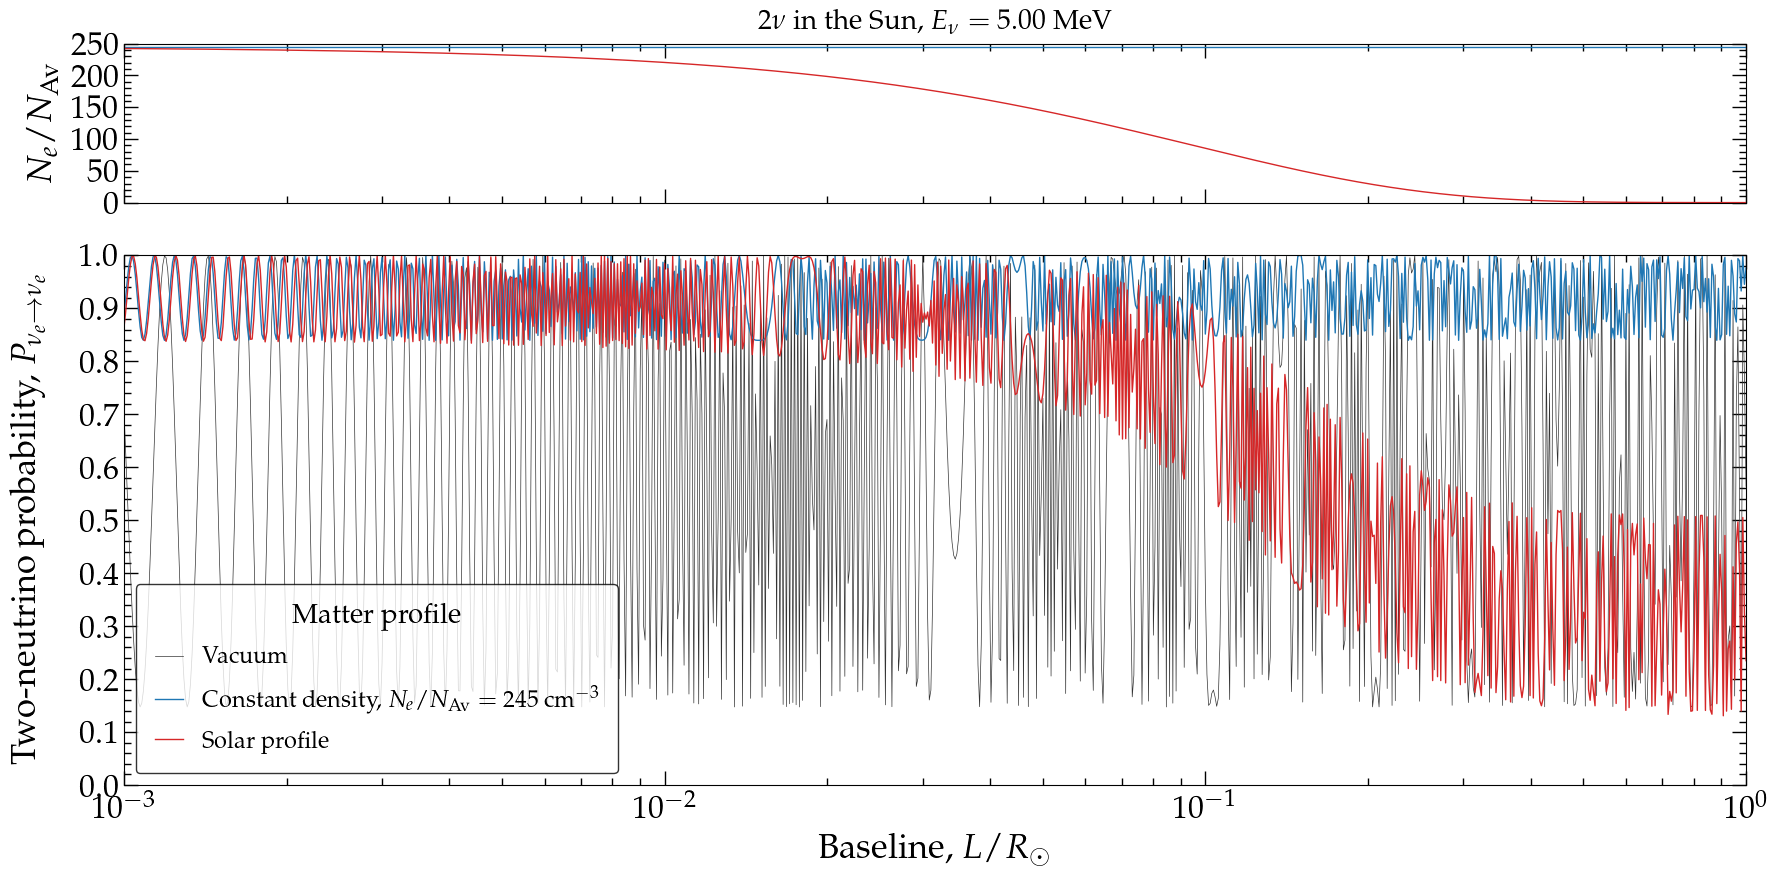

In [41]:
heights = [0.3, 1.0]
widths = [1.0]
gs_kw = dict(height_ratios=heights, width_ratios=widths)
fig, ax = plt.subplots(
    ncols=1, 
    nrows=2, 
    # constrained_layout=True, 
    gridspec_kw=gs_kw, 
    figsize=[18,9])
fig.subplots_adjust(hspace=0.05, wspace=0.05)

# Density profiles
ax[0].plot(distances, [num_density_e_center_sun/(gd.N_AV/pow(gd.CONV_CM_TO_INV_EV,3.0)) for l in distances], lw=1, ls='-', c='C0')
ax[0].plot(distances, [num_density_e_center_sun/(gd.N_AV/pow(gd.CONV_CM_TO_INV_EV,3.0))*np.exp(-l*gd.SUN_RADIUS/l_scale_sun)
                        for l in distances], lw=1, ls='-', c='C3')

# Probabilities
ax[1].plot(distances, prob_vac, lw=0.5, c='0.2', ls='-', label=r'Vacuum')
ax[1].plot(distances, prob_matt_const_density, lw=1, c='C0', ls='-', 
           label=r'Constant density, $N_e/N_{\rm Av} =~$'+'{:.0f}'.format(num_density_e_center_sun/(gd.N_AV/pow(gd.CONV_CM_TO_INV_EV,3.0))) \
           + r'~cm$^{-3}$')
ax[1].plot(distances, prob_matt_exp_density, lw=1, c='C3', ls='-', label=r'Solar profile')

# Legend
ax[1].legend(fontsize=17, frameon=True, loc='lower left', handlelength=1.2, handleheight=0.7,
             borderpad=0.8, title_fontsize=20, edgecolor='k', labelspacing=0.7, ncol=1, title=r'Matter profile')

# Formatting
ax[0].set_ylabel(r'$N_e/N_{\rm Av}$', labelpad=7)
ax[0].set_xscale('log')
ax[0].set_xlim(l_ini, l_fin)
ax[0].set_ylim(0, 250)
ax[0].yaxis.set_major_locator(mpl.ticker.MultipleLocator(base=50))
ax[0].yaxis.set_minor_locator(mpl.ticker.MultipleLocator(base=10))
ax[0].xaxis.set_ticklabels([])
ax[0].set_title(r'$2\nu$~in the Sun, $E_\nu = $~{:.2f}~MeV'.format(energy/gd.UNIT_MEV), fontsize=20, pad=10)
ax[1].set_xlabel(r'Baseline, $L/R_\odot$')
ax[1].set_ylabel(r'Two-neutrino probability,~'+prob_label(nu_i, nu_f), labelpad=25)
ax[1].set_xlim(l_ini, l_fin)
ax[1].set_ylim(0, 1)
ax[1].set_xscale('log')
ax[1].yaxis.set_major_locator(mpl.ticker.MultipleLocator(base=0.10))
ax[1].yaxis.set_minor_locator(mpl.ticker.MultipleLocator(base=0.02))

# Save plot
plt.tight_layout()
plt.savefig('../fig/prob_2nu_sun_vs_baseline.pdf', dpi=200)

## 7.3 Probabilities vs. energy

### Generate probabilities

In [42]:
# Energies
energy_min, energy_max = 1.e-1, 1.e2 # [MeV]
energy_npts = 1000
energies = np.logspace(np.log10(energy_min), np.log10(energy_max), energy_npts) # [MeV]

# Compute probability vs. energy
# osc_prob and osc_prob_2nu_vacuum_std return a 2x2 NumPy array with the probabilities: [[Pee, Pem], [Pme, Pmm]]
nu_i, nu_f = gd.NUE, gd.NUE # Initial and final flavors; can also choose NUMU or NUTAU
baseline = gd.SUN_RADIUS # [km]

H_vac_energy_indep = hamiltonians.hamiltonian_2nu_vacuum_energy_independent(sth, Dm2) # Vacuum H without (1/E) [eV^2]

# --------------------------------------------------------------
# In matter, constant density equal to central solar density
# --------------------------------------------------------------
H_matt = hamiltonians.hamiltonian_2nu_matter(VCC_func_const_density_sun(0.0)) # Matter Hamiltonian [eV]
def H_func_const_density(l, energy):
    return (1/energy)*H_vac_energy_indep+H_matt
prob_matt_const_density = np.array([oscprob.osc_prob(lambda l: H_func_const_density(l, enu*gd.UNIT_MEV), 
                                                     0.0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                     n_slabs=1, n_tpts_per_slab=10, magnus_exp_order=1)[nu_i][nu_f] for enu in energies])

# --------------------------------------------------------------
# In matter, solar matter density profile
# --------------------------------------------------------------
def H_func_exp_density(l, energy):
    return (1/energy)*H_vac_energy_indep+hamiltonians.hamiltonian_2nu_matter(VCC_func_exp_sun(l)) 
prob_matt_exp_density = np.array([oscprob.osc_prob(lambda l: H_func_exp_density(l, enu*gd.UNIT_MEV), 
                                                   0.0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                   n_slabs=200, n_tpts_per_slab=100, magnus_exp_order=2, n_jobs=10)[nu_i][nu_f] \
                                                   # n_slabs=200, n_tpts_per_slab=20, magnus_exp_order=3, n_jobs=8)[nu_i][nu_f] \
                                  for enu in energies])

# --------------------------------------------------------------
# In vacuum
# --------------------------------------------------------------
prob_vac = np.array([oscprob.osc_prob(lambda l: (1/(enu*gd.UNIT_MEV))*H_vac_energy_indep, 
                                      0.0, baseline*gd.CONV_KM_TO_INV_EV, 
                                      n_slabs=1, n_tpts_per_slab=10, magnus_exp_order=1)[nu_i][nu_f] for enu in energies])

/tmp/ipykernel_282578/2392756941.py:19: ToleranceNotAchievedWarning: osc_prob: requested tolerance not achieved (max_n_slabs reached), so convergence could not be verified by successive refinement; the returned probabilities may be inaccurate. Try increasing max_n_slabs. This can happen for very large accumulated phases, e.g., low-energy neutrinos over very long baselines, or eV-scale sterile splittings over Earth-crossing baselines. Shown once per session.
  prob_matt_const_density = np.array([oscprob.osc_prob(lambda l: H_func_const_density(l, enu*gd.UNIT_MEV),


/home/mbustamante/Research/magnus/src/magnus/magnus.py:1040: MagnusConvergenceWarning: at least one time slab is too wide for guaranteed convergence of the Magnus series (||Omega||_2 >= pi); raising the expansion order will not help there -- more (narrower) slabs are needed. If a target tolerance (rtol/atol) was requested, the adaptive refinement narrows the slabs automatically and this warning can be ignored. Shown once per session.
  return evolution_operators_from_samples(At, widths, order,
/tmp/ipykernel_282578/2392756941.py:28: ToleranceNotAchievedWarning: osc_prob: requested tolerance not achieved (max_n_slabs reached), so convergence could not be verified by successive refinement; the returned probabilities may be inaccurate. Try increasing max_n_slabs. This can happen for very large accumulated phases, e.g., low-energy neutrinos over very long baselines, or eV-scale sterile splittings over Earth-crossing baselines. Shown once per session.
  prob_matt_exp_density = np.array([osc

/tmp/ipykernel_282578/2392756941.py:37: ToleranceNotAchievedWarning: osc_prob: requested tolerance not achieved (max_n_slabs reached), so convergence could not be verified by successive refinement; the returned probabilities may be inaccurate. Try increasing max_n_slabs. This can happen for very large accumulated phases, e.g., low-energy neutrinos over very long baselines, or eV-scale sterile splittings over Earth-crossing baselines. Shown once per session.
  prob_vac = np.array([oscprob.osc_prob(lambda l: (1/(enu*gd.UNIT_MEV))*H_vac_energy_indep,


### Plot probabilities

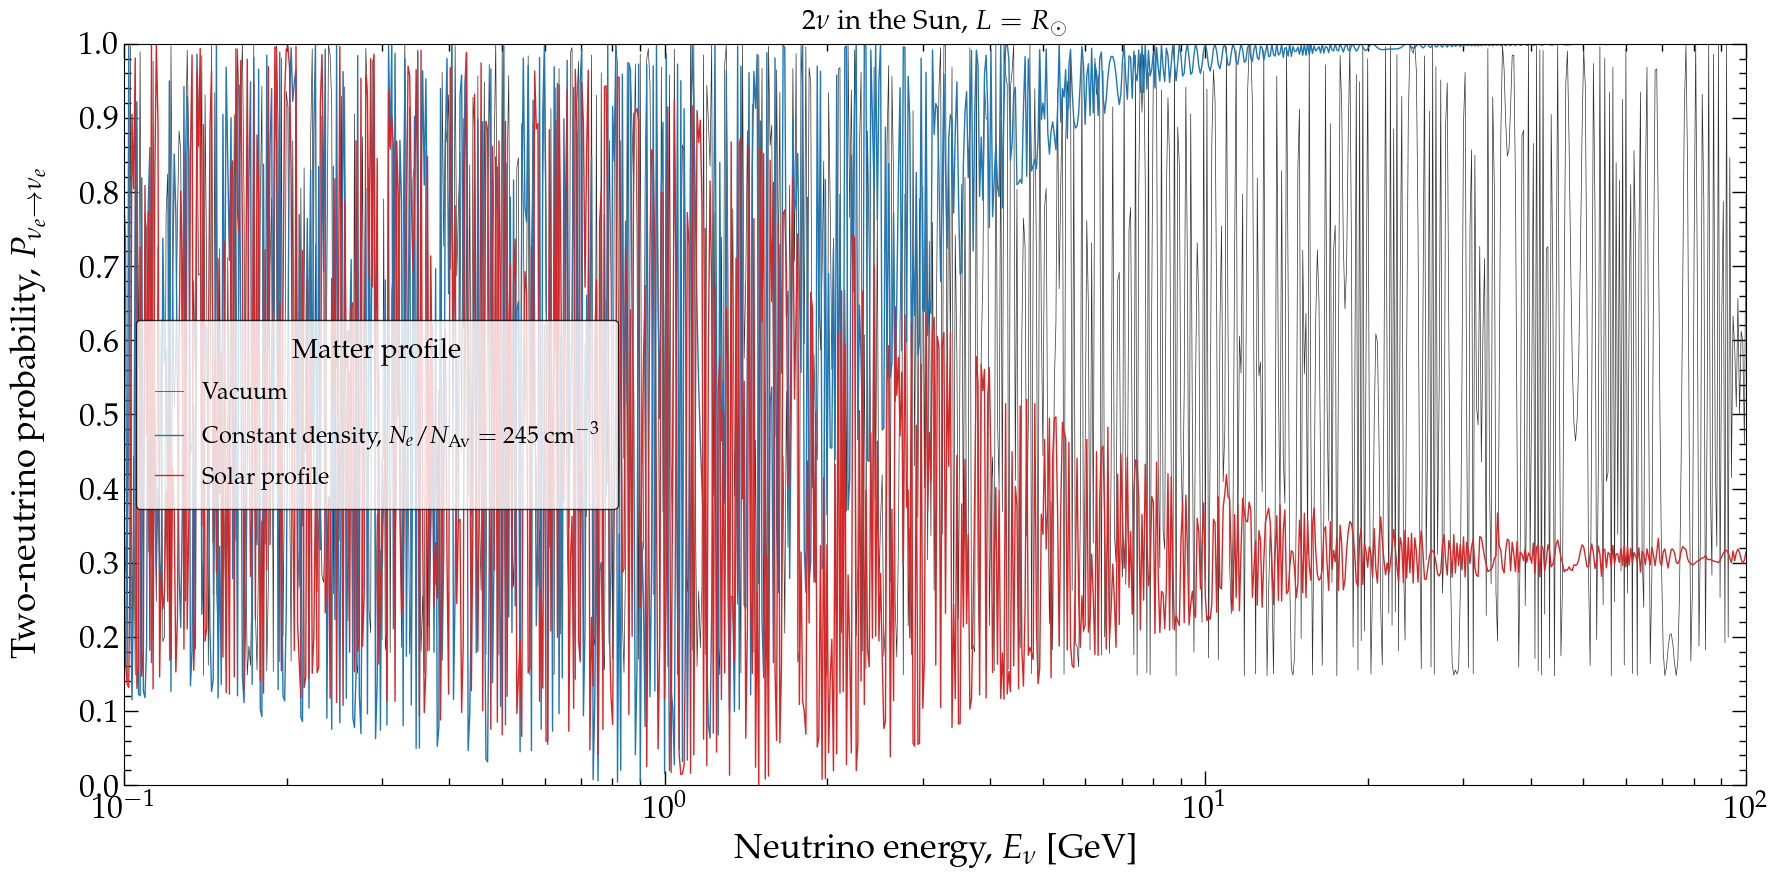

In [43]:
heights = [1.0]
widths = [1.0]
gs_kw = dict(height_ratios=heights, width_ratios=widths)
fig, ax = plt.subplots(
    ncols=1, 
    nrows=1, 
    gridspec_kw=gs_kw, 
    figsize=[18,9])
fig.subplots_adjust(hspace=0.05, wspace=0.05)


# Probabilities
ax.plot(energies, prob_vac, lw=0.5, c='0.2', ls='-', label=r'Vacuum')
ax.plot(energies, prob_matt_const_density, lw=1, c='C0', ls='-', 
           label=r'Constant density, $N_e/N_{\rm Av} =~$'+'{:.0f}'.format(num_density_e_center_sun/(gd.N_AV/pow(gd.CONV_CM_TO_INV_EV,3.0))) \
           + r'~cm$^{-3}$')
ax.plot(energies, prob_matt_exp_density, lw=1, c='C3', ls='-', label=r'Solar profile')

# Legend
ax.legend(fontsize=17, frameon=True, loc='center left', handlelength=1.2, handleheight=0.7, 
          borderpad=0.8, title_fontsize=20, edgecolor='k', labelspacing=0.7, ncol=1, title=r'Matter profile') 

# Formatting
ax.set_title(r'$2\nu$~in the Sun, $L = R_\odot$', fontsize=20, pad=10)
ax.set_xlabel(r'Neutrino energy, $E_\nu$ [GeV]')
ax.set_ylabel(r'Two-neutrino probability,~'+prob_label(nu_i, nu_f), labelpad=25)
ax.set_xlim(energy_min, energy_max)
ax.set_ylim(0, 1)
ax.set_xscale('log')
ax.yaxis.set_major_locator(mpl.ticker.MultipleLocator(base=0.10))
ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(base=0.02))

# Save plot
plt.tight_layout()
plt.savefig('../fig/prob_2nu_sun_vs_energy.pdf', dpi=200)